In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Here we load the results of the FGSM and PGD attacks on the PCAM dataset, and plot the results.

In [10]:
results_fgsm_no_aug_csv = '../results/fgsm/results_fgsm.csv'
results_fgsm_aug_csv = '../results/fgsm_aug/results_fgsm_aug.csv'
results_pgd_no_aug_csv = '../results/pgd/results_pgd.csv'
results_pgd_aug_csv = '../results/pgd_aug/results_pgd_aug.csv'

In [11]:
results_fgsm_no_aug = pd.read_csv(results_fgsm_no_aug_csv)
results_fgsm_aug = pd.read_csv(results_fgsm_aug_csv)
results_pgd_no_aug = pd.read_csv(results_pgd_no_aug_csv)
results_pgd_aug = pd.read_csv(results_pgd_aug_csv)

In [12]:
print("Results for FGSM without augmentation:")
display(results_fgsm_no_aug.sort_values(by="metric", ascending=False).head())
print("Results for FGSM with augmentation:")
display(results_fgsm_aug.sort_values(by="metric", ascending=False).head())
print("Results for PGD without augmentation:")
display(results_pgd_no_aug.sort_values(by="metric", ascending=False).head())
print("Results for PGD with augmentation:")
display(results_pgd_aug.sort_values(by="metric", ascending=False).head())

Results for FGSM without augmentation:


,attack,defense,metric
156,none,"GaussianSmoothing (k=5, sigma=0.4)",0.9252
152,none,"GaussianSmoothing (k=3, sigma=0.4)",0.9252
151,none,"GaussianSmoothing (k=3, sigma=0.2)",0.9249
155,none,"GaussianSmoothing (k=5, sigma=0.2)",0.9249
0,none,none,0.9249


Results for FGSM with augmentation:


,attack,defense,metric
160,none,JpegCompression (q=70),0.9421
161,none,JpegCompression (q=90),0.9418
155,none,"GaussianSmoothing (k=5, sigma=0.2)",0.9400
151,none,"GaussianSmoothing (k=3, sigma=0.2)",0.9400
0,none,none,0.9400


Results for PGD without augmentation:


,attack,defense,metric
156,none,"GaussianSmoothing (k=5, sigma=0.4)",0.9252
152,none,"GaussianSmoothing (k=3, sigma=0.4)",0.9252
151,none,"GaussianSmoothing (k=3, sigma=0.2)",0.9249
155,none,"GaussianSmoothing (k=5, sigma=0.2)",0.9249
0,none,none,0.9249


Results for PGD with augmentation:


,attack,defense,metric
160,none,JpegCompression (q=70),0.9421
161,none,JpegCompression (q=90),0.9418
155,none,"GaussianSmoothing (k=5, sigma=0.2)",0.9400
151,none,"GaussianSmoothing (k=3, sigma=0.2)",0.9400
0,none,none,0.9400


# Plot

We will define a function to save the plots in PNG format.

In [17]:
def save_figure(fig, filename: str, folder: str = "img/pgd_aug"):
    from pathlib import Path
    
    img_dir = Path(folder)
    img_dir.mkdir(parents=True, exist_ok=True)
    base_path = img_dir / filename
    
    # Save in multiple formats
    fig.savefig(f"{base_path}.png", bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    print(f"Saved publication-quality figures: {base_path}.[png]")

The accuracy heatmap shows the accuracy of the model on each of the attack types and for each of the defense methods. We also added the attack and defense none (clean data) to the heatmap as a reference.

In [18]:
def plot_accuracy_heatmap(df: pd.DataFrame, save_fig: bool = True, metric: str = 'AUROC', folder: str = "img/fgsm"):
    """Plot publication-quality accuracy heatmap for attack-defense combinations."""
    
    pivot_table = df.pivot(index='attack', columns='defense', values='metric')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Use a more sophisticated colormap
    mask = pivot_table.isnull()
    
    sns.heatmap(pivot_table, 
                annot=True, 
                fmt='.3f',
                cmap='YlGn',
                center=0.5,
                square=False,
                linewidths=0.5,
                linecolor='white',
                cbar_kws={
                    'label': f'{metric.upper()}',
                    'shrink': 0.8,
                    'aspect': 20
                },
                ax=ax,
                mask=mask)
    
    ax.set_title('Defense Effectiveness Against Adversarial Attacks', 
                fontweight='bold', pad=20)
    ax.set_xlabel('Defense Method', fontweight='bold')
    ax.set_ylabel('Attack Method', fontweight='bold')
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    if save_fig:
        save_figure(fig, "attack_defense_heatmap", folder=folder)
    
    plt.show()

Saved publication-quality figures: ../img/fgsm/attack_defense_heatmap.[png]


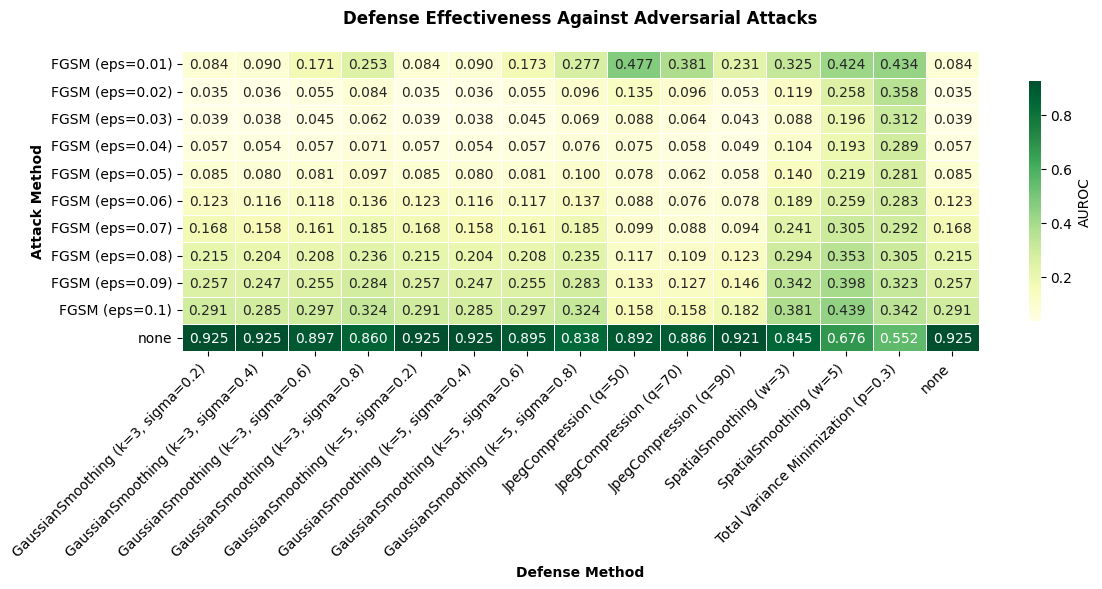

Saved publication-quality figures: ../img/fgsm_aug/attack_defense_heatmap.[png]


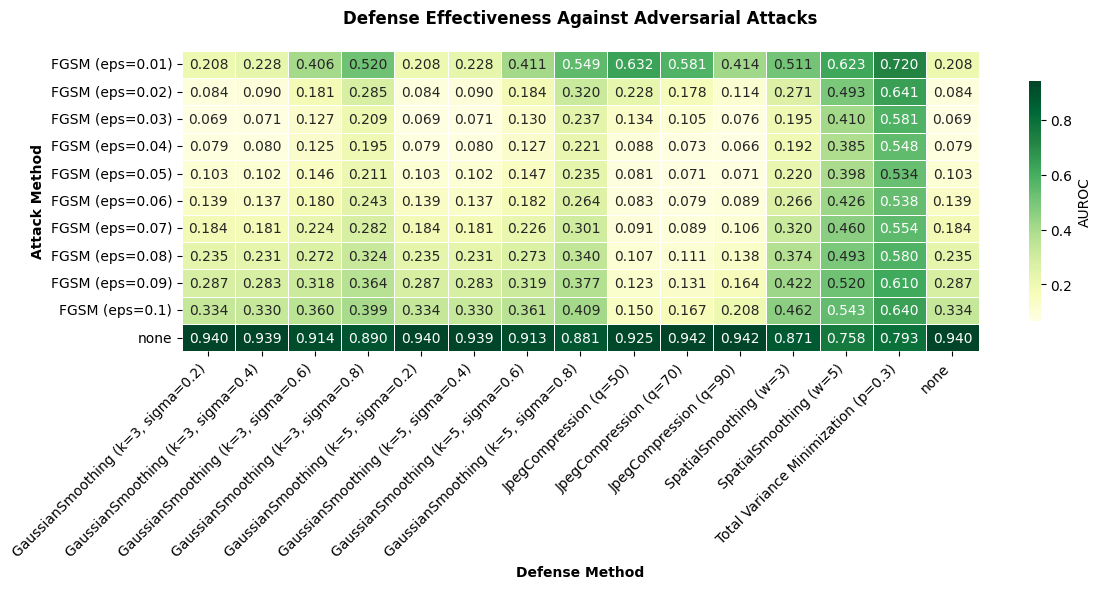

Saved publication-quality figures: ../img/pgd/attack_defense_heatmap.[png]


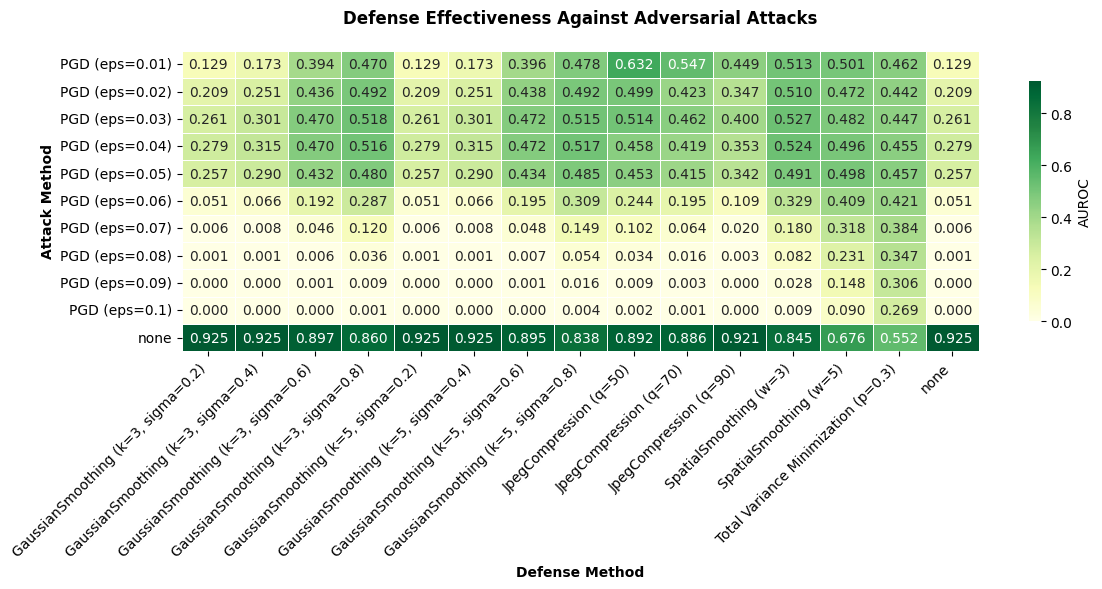

Saved publication-quality figures: ../img/pgd_aug/attack_defense_heatmap.[png]


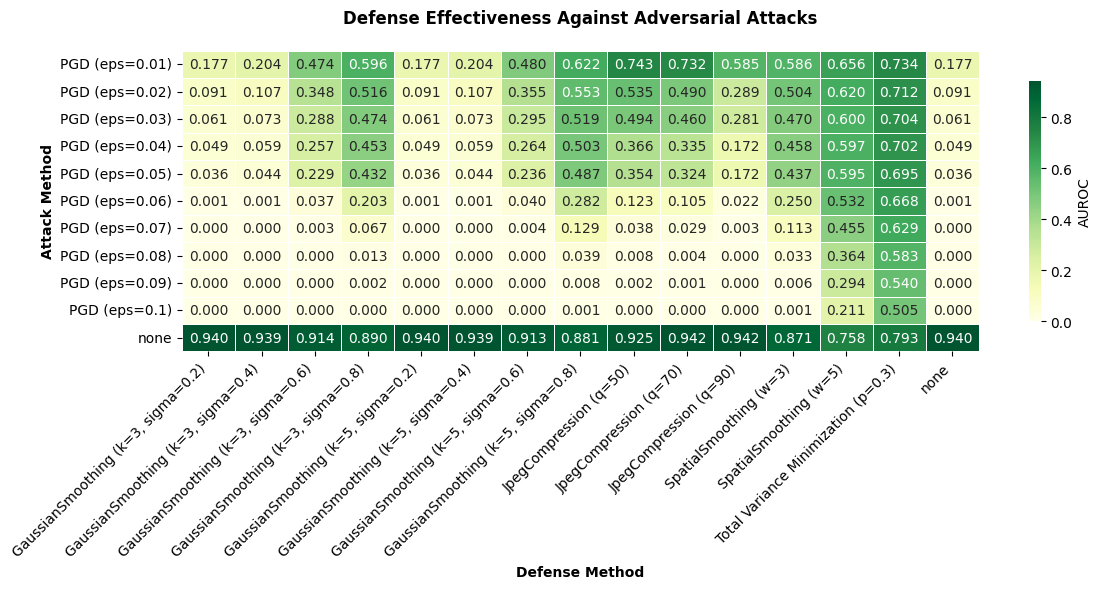

In [ ]:
plot_accuracy_heatmap(results_fgsm_no_aug, save_fig=True, metric='AUROC', folder="../img/fgsm")
plot_accuracy_heatmap(results_fgsm_aug, save_fig=True, metric='AUROC', folder="../img/fgsm_aug")
plot_accuracy_heatmap(results_pgd_no_aug, save_fig=True, metric='AUROC', folder="../img/pgd")
plot_accuracy_heatmap(results_pgd_aug, save_fig=True, metric='AUROC', folder="../img/pgd_aug")

Defense metric function will be used to calculate the accuracy of the model on the attacked images.

In [19]:
def defence_metric(df: pd.DataFrame, save_fig: bool = True, metric: str = 'AUROC', defence_name: str = 'all', folder: str = "img/fgsm"):

    if defence_name != 'all':
        df = df[(df['defense'].str.contains(defence_name)) | (df['defense'] == 'none')]

    attacks = [name for name in df['attack'].unique() if name != 'none']
    defenses = df['defense'].unique()
    defenses = [defense for defense in defenses if defense != 'none']
    
    # Get clean accuracy for baseline
    clean_acc = df[(df['attack'] == 'none') & (df['defense'] == 'none')]['metric'].values[0]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define professional color palette
    colors = plt.cm.Set2(np.linspace(0, 1, len(defenses)))

    # Plot each defense's performance against attacks
    for i, defense in enumerate(defenses):
        defense_results = df[df['defense'] == defense]
        attack_accuracies = []
        
        for attack in attacks:
            acc = defense_results[defense_results['attack'] == attack]['metric'].values
            attack_accuracies.append(acc[0] if len(acc) > 0 else 0)
        
        # Plot with markers and error styling
        x_pos = range(len(attacks))
        ax.plot(x_pos, attack_accuracies, 
                marker='o', linewidth=2.5, markersize=8, 
                label=defense, color=colors[i], alpha=0.9,
                markerfacecolor='white', markeredgewidth=2, markeredgecolor=colors[i])
        
        # Add value annotations with better positioning
        for j, acc in enumerate(attack_accuracies):
            ax.annotate(f'{acc:.3f}', (j, acc), 
                        textcoords="offset points", xytext=(0, 15), 
                        ha='center', fontsize=10, alpha=0.8,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Add clean baseline
    ax.axhline(y=clean_acc, color='black', linestyle='--', alpha=0.6, linewidth=2,
                label=f'Clean Baseline ({clean_acc:.3f})')
    
    ax.set_xlabel('Attack Method', fontweight='bold')
    ax.set_ylabel(f'{metric.upper()}', fontweight='bold')
    ax.set_title('Defense Robustness Across Attacks', fontweight='bold')
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.set_xticks(range(len(attacks)))
    ax.set_xticklabels(attacks, rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    
    if save_fig:
        save_figure(fig, f"defense_metric_{defence_name}", folder=folder)
    plt.show()

Saved publication-quality figures: ../img/fgsm/defense_metric_Gaussian.[png]


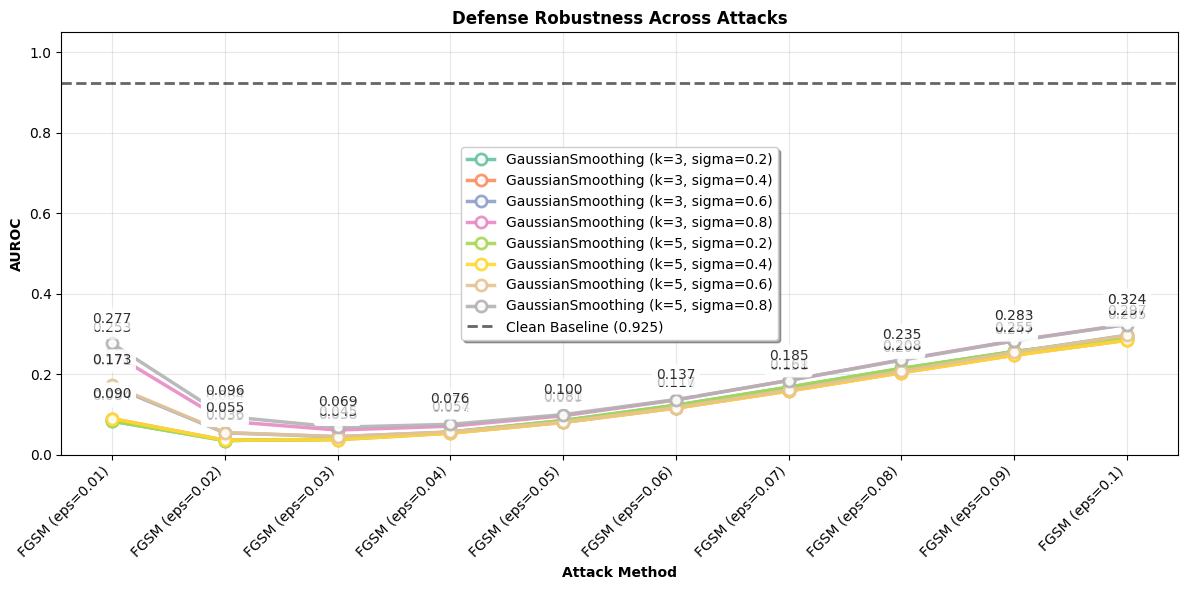

Saved publication-quality figures: ../img/fgsm/defense_metric_Spatial.[png]


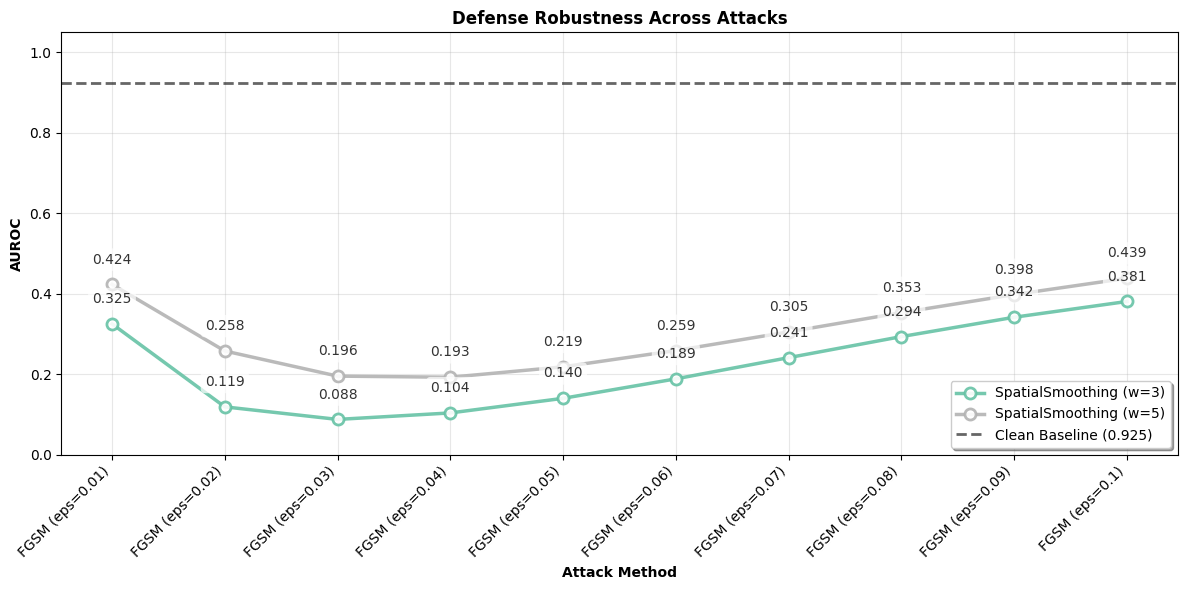

Saved publication-quality figures: ../img/fgsm/defense_metric_Variance.[png]


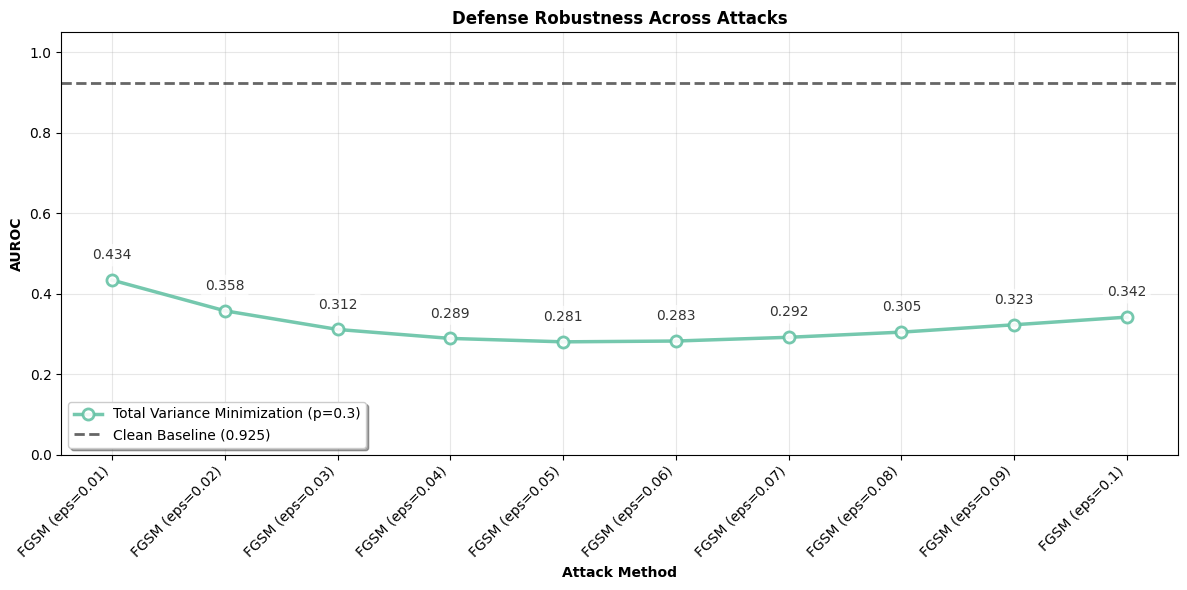

Saved publication-quality figures: ../img/fgsm/defense_metric_Jpeg.[png]


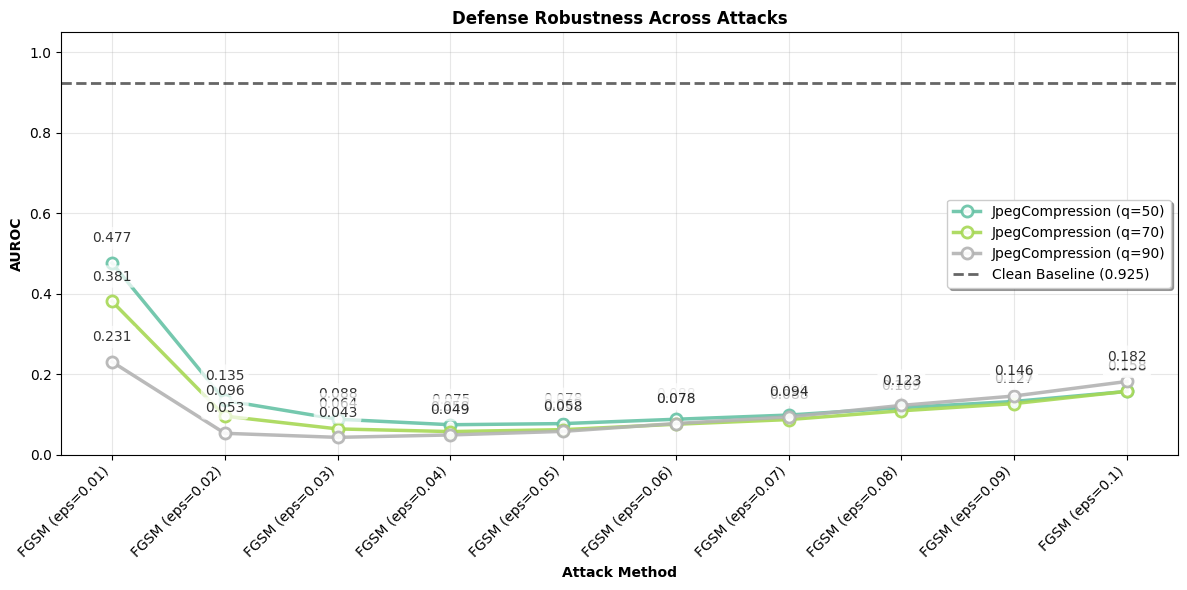

In [20]:
defence_metric(results_fgsm_no_aug, save_fig=True, metric='AUROC', defence_name='Gaussian', folder="../img/fgsm")
defence_metric(results_fgsm_no_aug, save_fig=True, metric='AUROC', defence_name='Spatial', folder="../img/fgsm")
defence_metric(results_fgsm_no_aug, save_fig=True, metric='AUROC', defence_name='Variance', folder="../img/fgsm")
defence_metric(results_fgsm_no_aug, save_fig=True, metric='AUROC', defence_name='Jpeg', folder="../img/fgsm")

With the augmentation comparison, we aim to compare the performance of the model on the model without augmentation and with augmentation. The augmentation is applied to the training data, and we will compare the accuracy of the model on the attacked images with and without augmentation. This is to assess the effectiveness of the augmentation in improving the model's robustness against adversarial attacks.

In [43]:
def plot_augmentation_comparison(df_no_aug: pd.DataFrame, df_aug: pd.DataFrame, 
                                save_fig: bool = True, metric: str = 'AUROC', 
                                defence_name: str = 'all', folder: str = "img/comparison"):
    """
    Plot side-by-side comparison of defense performance with and without data augmentation.
    """
    
    # Filter data if specific defense is requested
    if defence_name != 'all':
        df_no_aug = df_no_aug[(df_no_aug['defense'].str.contains(defence_name)) | (df_no_aug['defense'] == 'none')]
        df_aug = df_aug[(df_aug['defense'].str.contains(defence_name)) | (df_aug['defense'] == 'none')]
    
    # Get common attacks and defenses
    attacks_no_aug = set(name for name in df_no_aug['attack'].unique() if name != 'none')
    attacks_aug = set(name for name in df_aug['attack'].unique() if name != 'none')
    common_attacks = sorted(attacks_no_aug.intersection(attacks_aug))
    
    defenses_no_aug = set(defense for defense in df_no_aug['defense'].unique())
    defenses_aug = set(defense for defense in df_aug['defense'].unique())
    common_defenses = sorted(defenses_no_aug.intersection(defenses_aug))
    
    # Get clean accuracy for baseline
    clean_acc_no_aug = df_no_aug[(df_no_aug['attack'] == 'none') & (df_no_aug['defense'] == 'none')]['metric'].values[0]
    clean_acc_aug = df_aug[(df_aug['attack'] == 'none') & (df_aug['defense'] == 'none')]['metric'].values[0]
    
    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Define professional color palette
    colors = plt.cm.Set3(np.linspace(0, 1, len(common_defenses)))
    
    # Plot without augmentation (left subplot)
    for i, defense in enumerate(common_defenses):
        defense_results = df_no_aug[df_no_aug['defense'] == defense]
        attack_accuracies = []

        if defense == 'none':
            defense = 'No Defense'
        
        for attack in common_attacks:
            acc = defense_results[defense_results['attack'] == attack]['metric'].values
            attack_accuracies.append(acc[0] if len(acc) > 0 else 0)
        
        x_pos = range(len(common_attacks))
        ax1.plot(x_pos, attack_accuracies, 
                marker='o', linewidth=2.5, markersize=8, 
                label=defense, color=colors[i], alpha=0.9,
                markerfacecolor='white', markeredgewidth=2, markeredgecolor=colors[i])
        
        # Add value annotations
        for j, acc in enumerate(attack_accuracies):
            ax1.annotate(f'{acc:.3f}', (j, acc), 
                        textcoords="offset points", xytext=(0, 15), 
                        ha='center', fontsize=9, alpha=0.8,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Add clean baseline for no augmentation
    ax1.axhline(y=clean_acc_no_aug, color='black', linestyle='--', alpha=0.6, linewidth=2,
                label=f'Clean Baseline ({clean_acc_no_aug:.3f})')
    
    ax1.set_xlabel('Attack Method', fontweight='bold')
    ax1.set_ylabel(f'{metric.upper()}', fontweight='bold')
    ax1.set_title('Without Data Augmentation', fontweight='bold', fontsize=14)
    ax1.legend(frameon=True, fancybox=True, shadow=True, loc='best')
    ax1.set_xticks(range(len(common_attacks)))
    ax1.set_xticklabels(common_attacks, rotation=45, ha='right')
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, alpha=0.3)
    
    # Plot with augmentation (right subplot)
    for i, defense in enumerate(common_defenses):
        defense_results = df_aug[df_aug['defense'] == defense]
        attack_accuracies = []

        if defense == 'none':
            defense = 'No Defense'
        
        for attack in common_attacks:
            acc = defense_results[defense_results['attack'] == attack]['metric'].values
            attack_accuracies.append(acc[0] if len(acc) > 0 else 0)
        
        x_pos = range(len(common_attacks))
        ax2.plot(x_pos, attack_accuracies, 
                marker='o', linewidth=2.5, markersize=8, 
                label=defense, color=colors[i], alpha=0.9,
                markerfacecolor='white', markeredgewidth=2, markeredgecolor=colors[i])
        
        # Add value annotations
        for j, acc in enumerate(attack_accuracies):
            ax2.annotate(f'{acc:.3f}', (j, acc), 
                        textcoords="offset points", xytext=(0, 15), 
                        ha='center', fontsize=9, alpha=0.8,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Add clean baseline for augmentation
    ax2.axhline(y=clean_acc_aug, color='black', linestyle='--', alpha=0.6, linewidth=2,
                label=f'Clean Baseline ({clean_acc_aug:.3f})')
    
    ax2.set_xlabel('Attack Method', fontweight='bold')
    ax2.set_ylabel(f'{metric.upper()}', fontweight='bold')
    ax2.set_title('With Data Augmentation', fontweight='bold', fontsize=14)
    ax2.legend(frameon=True, fancybox=True, shadow=True, loc='best')
    ax2.set_xticks(range(len(common_attacks)))
    ax2.set_xticklabels(common_attacks, rotation=45, ha='right')
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, alpha=0.3)
    
    # Add overall title
    fig.suptitle(f'Defense Robustness Comparison: {defence_name.title()} Defenses', 
                fontweight='bold', fontsize=16, y=0.98)
    
    plt.tight_layout()
    
    if save_fig:
        save_figure(fig, f"augmentation_comparison_{defence_name}", folder=folder)
    plt.show()

Saved publication-quality figures: ../img/comparison/fgsm/augmentation_comparison_Gaussian.[png]


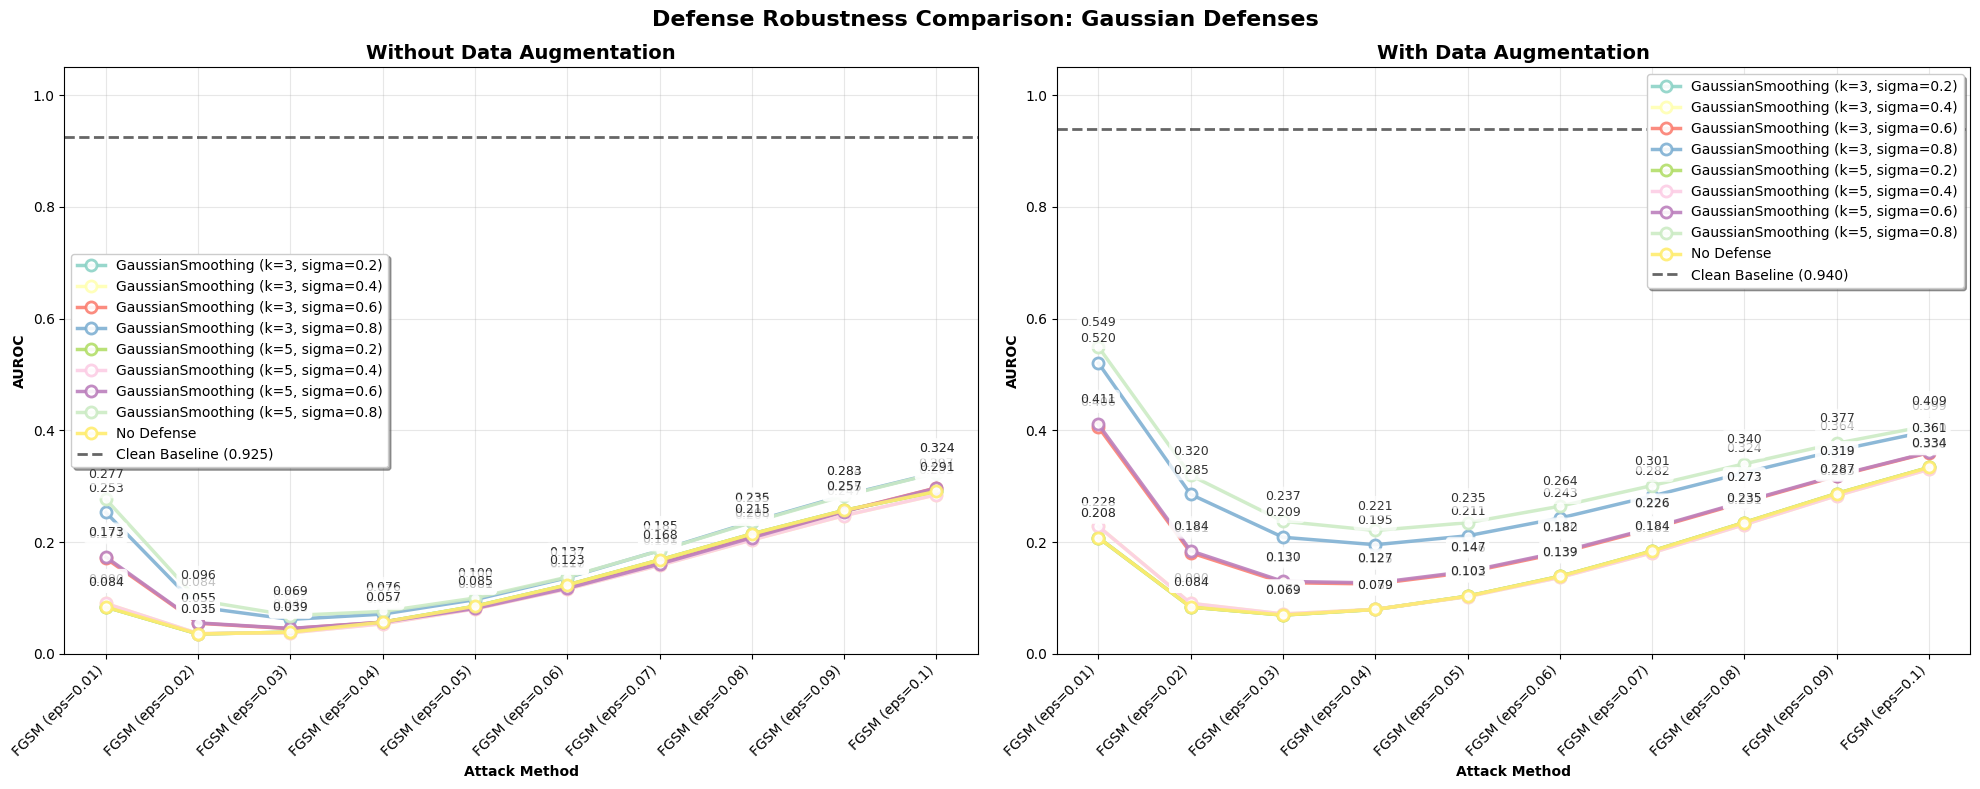

Saved publication-quality figures: ../img/comparison/pgd/augmentation_comparison_Gaussian.[png]


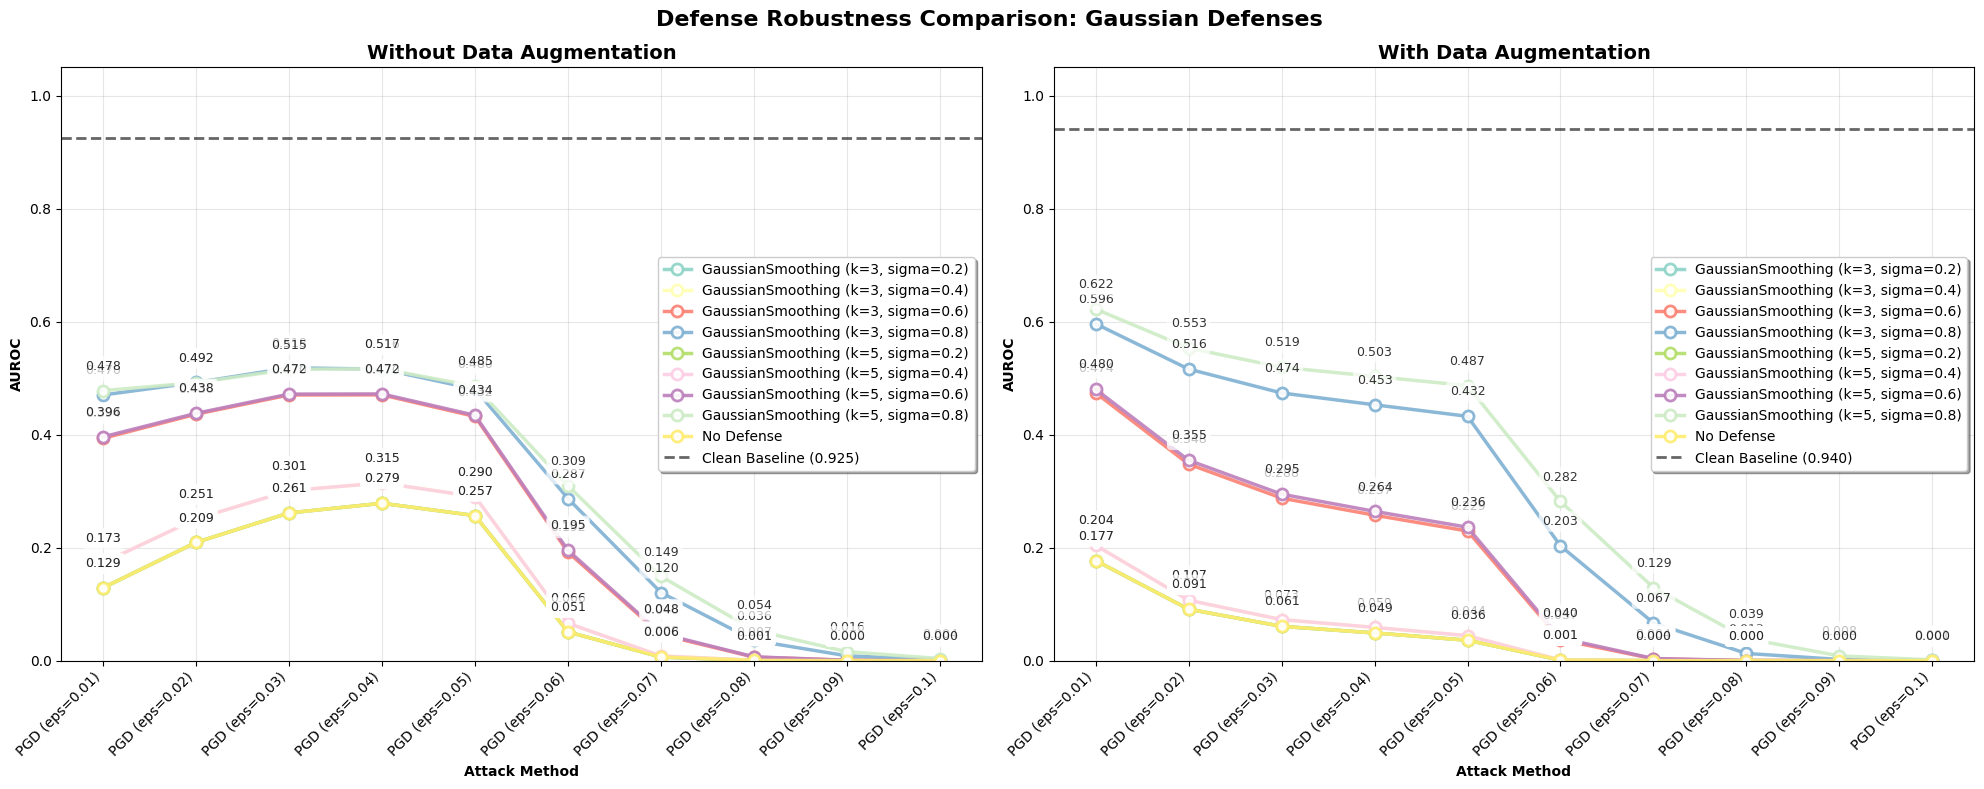

Saved publication-quality figures: ../img/comparison/fgsm/augmentation_comparison_Spatial.[png]


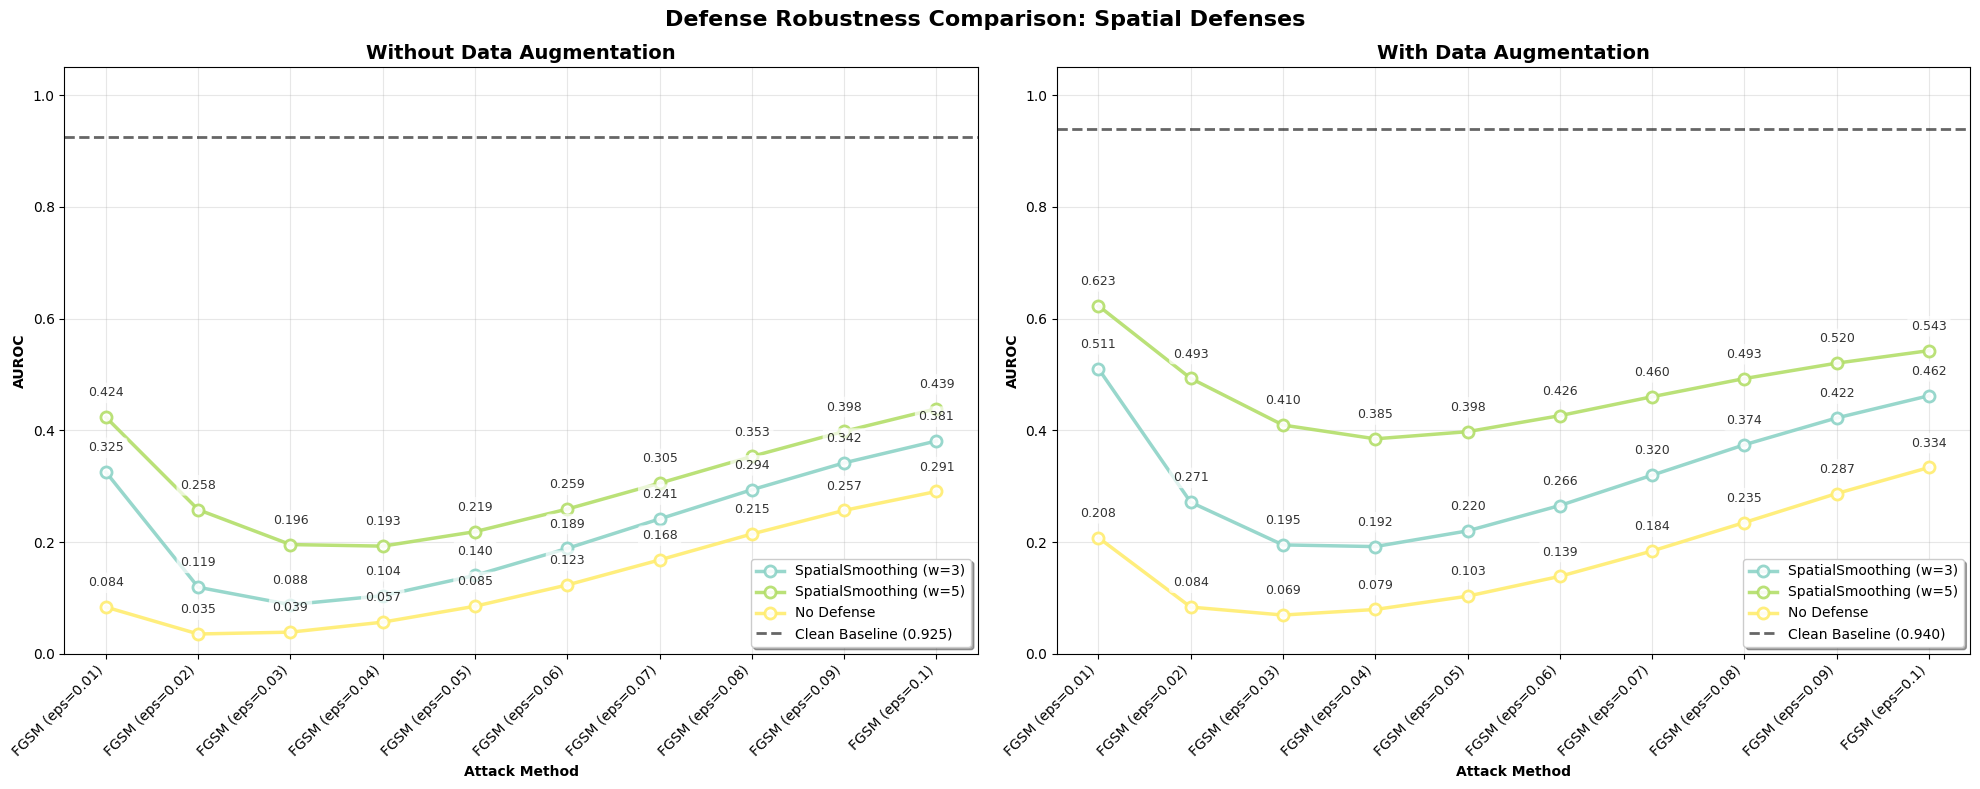

Saved publication-quality figures: ../img/comparison/pgd/augmentation_comparison_Spatial.[png]


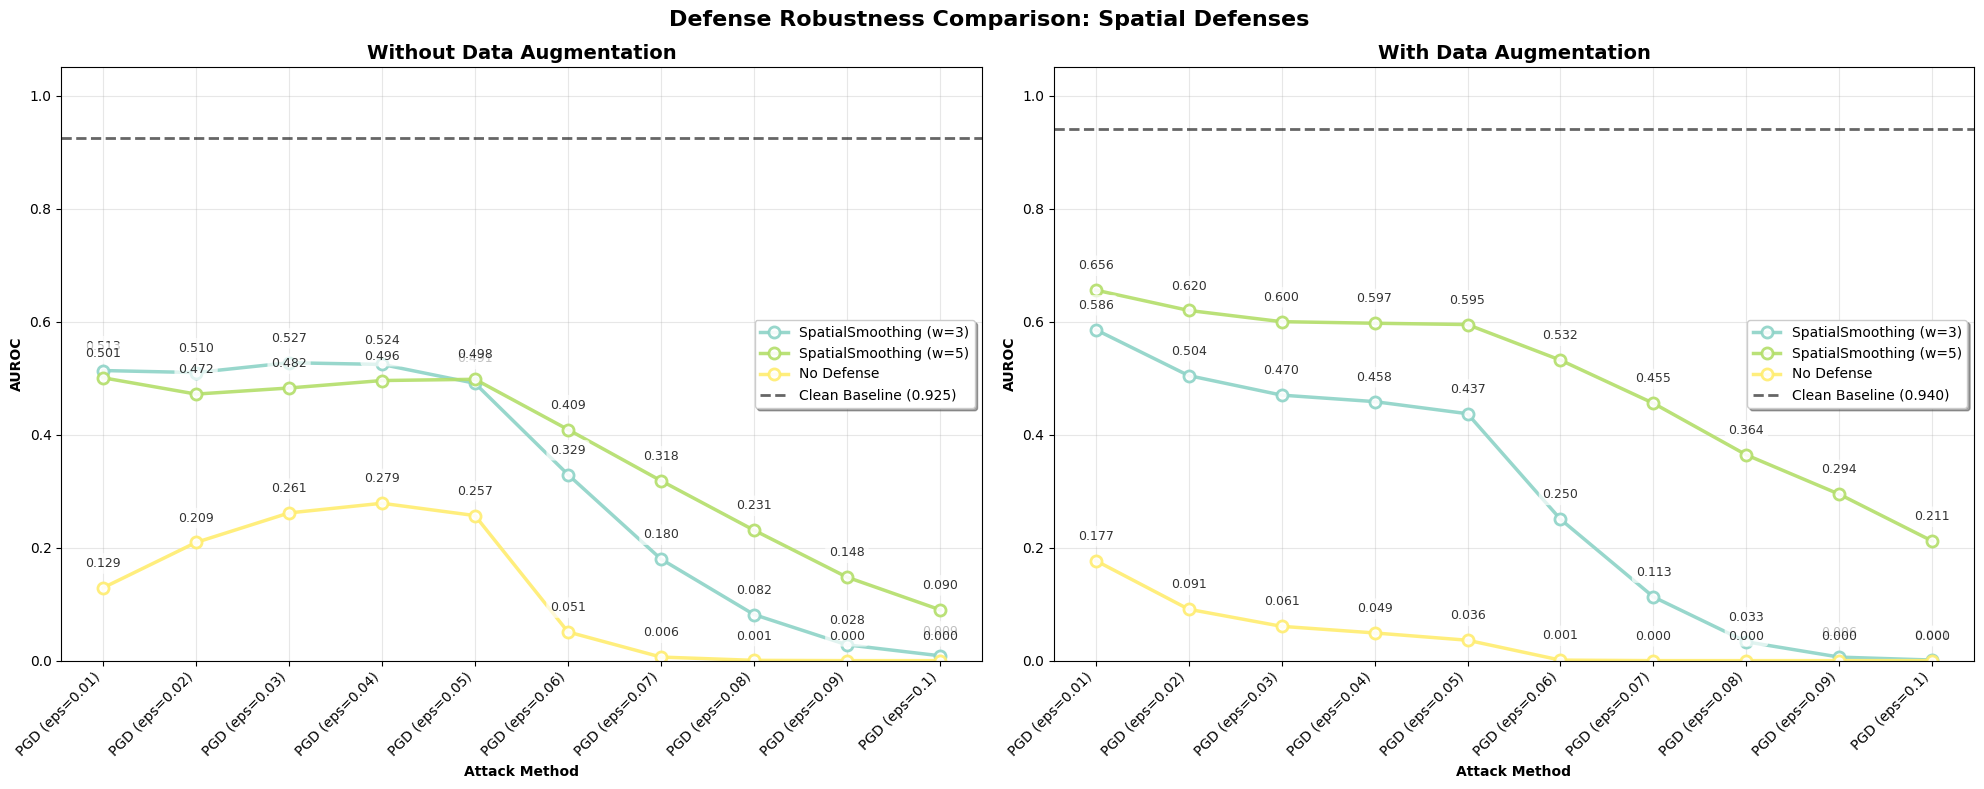

Saved publication-quality figures: ../img/comparison/fgsm/augmentation_comparison_Variance.[png]


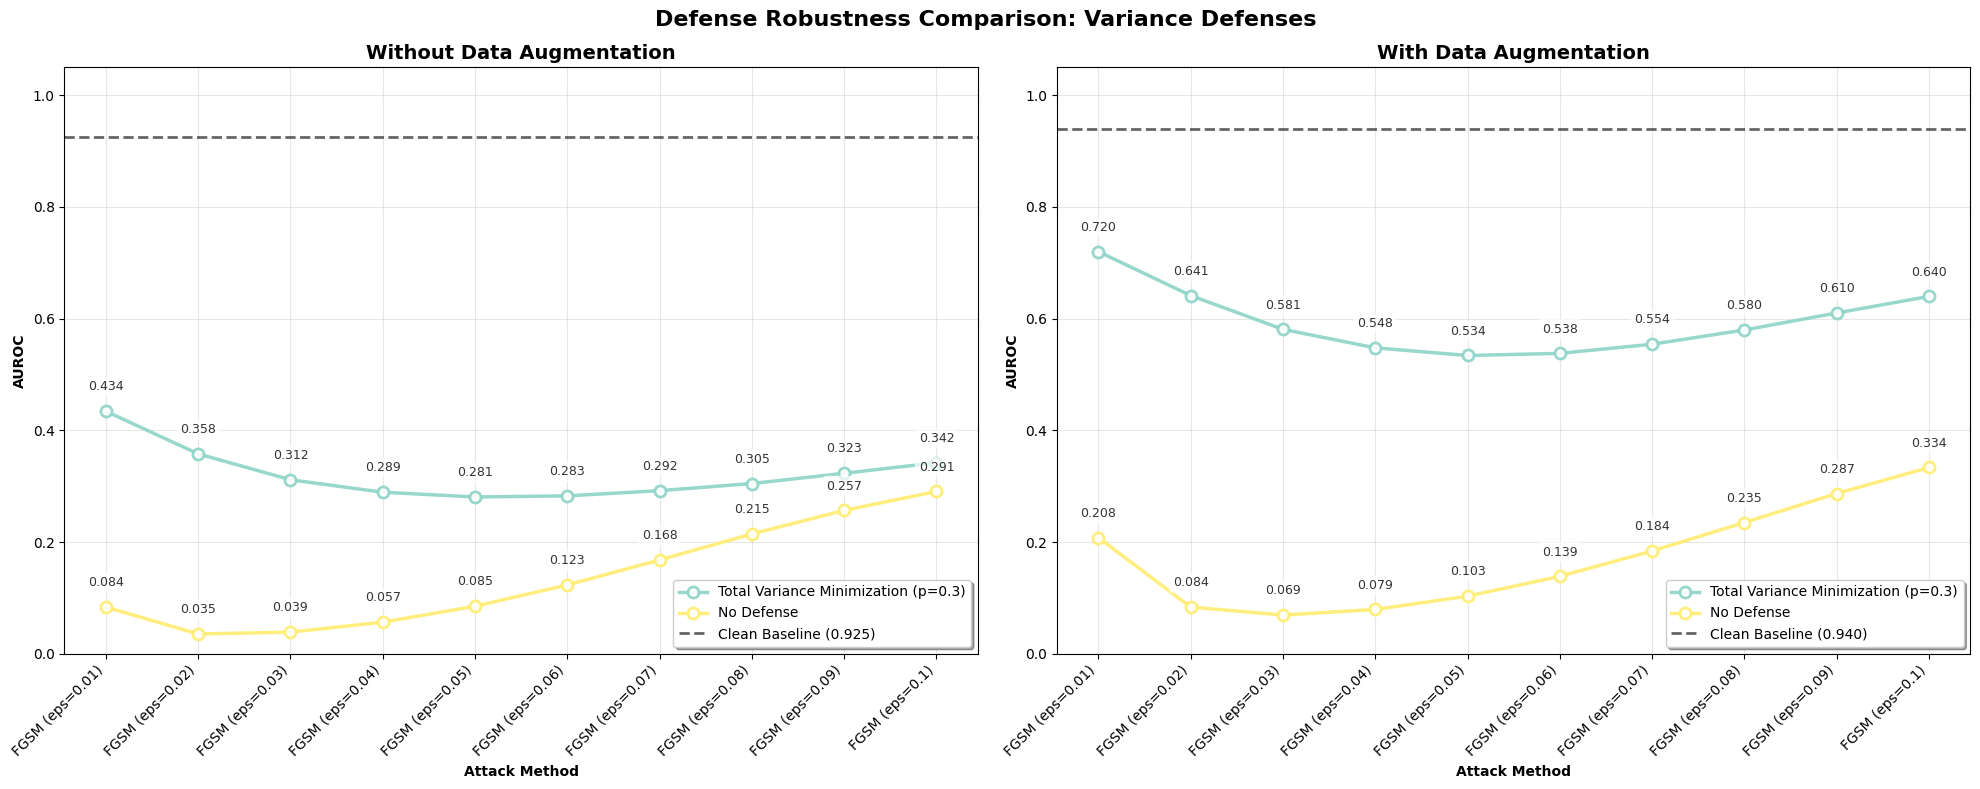

Saved publication-quality figures: ../img/comparison/pgd/augmentation_comparison_Variance.[png]


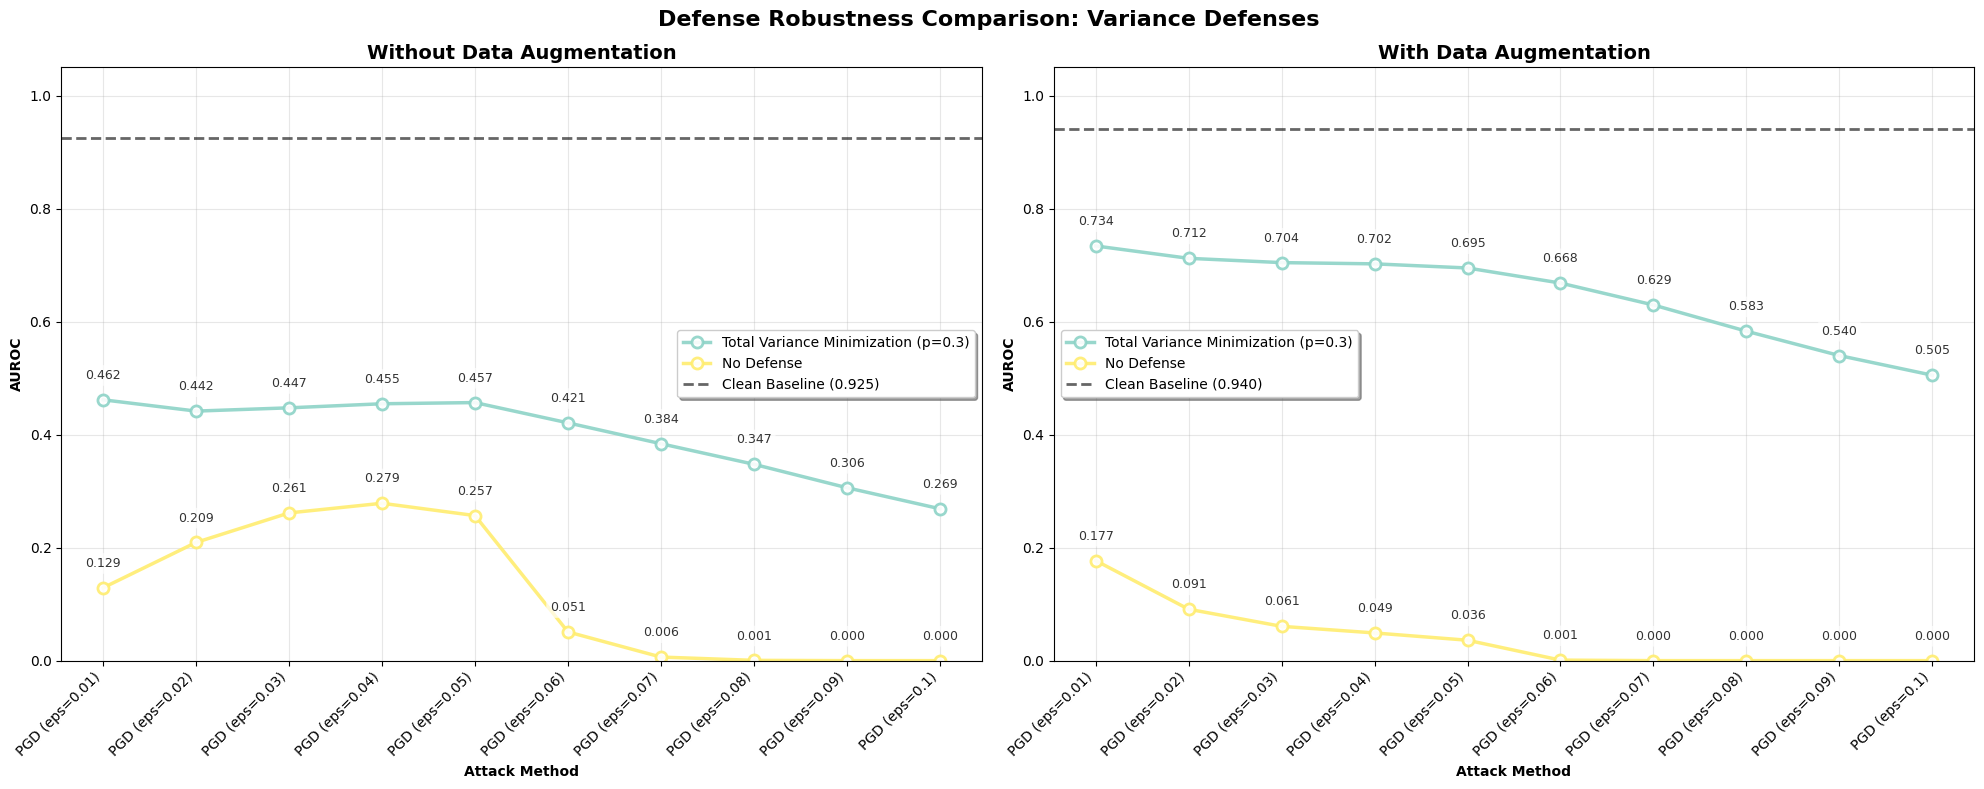

Saved publication-quality figures: ../img/comparison/fgsm/augmentation_comparison_Jpeg.[png]


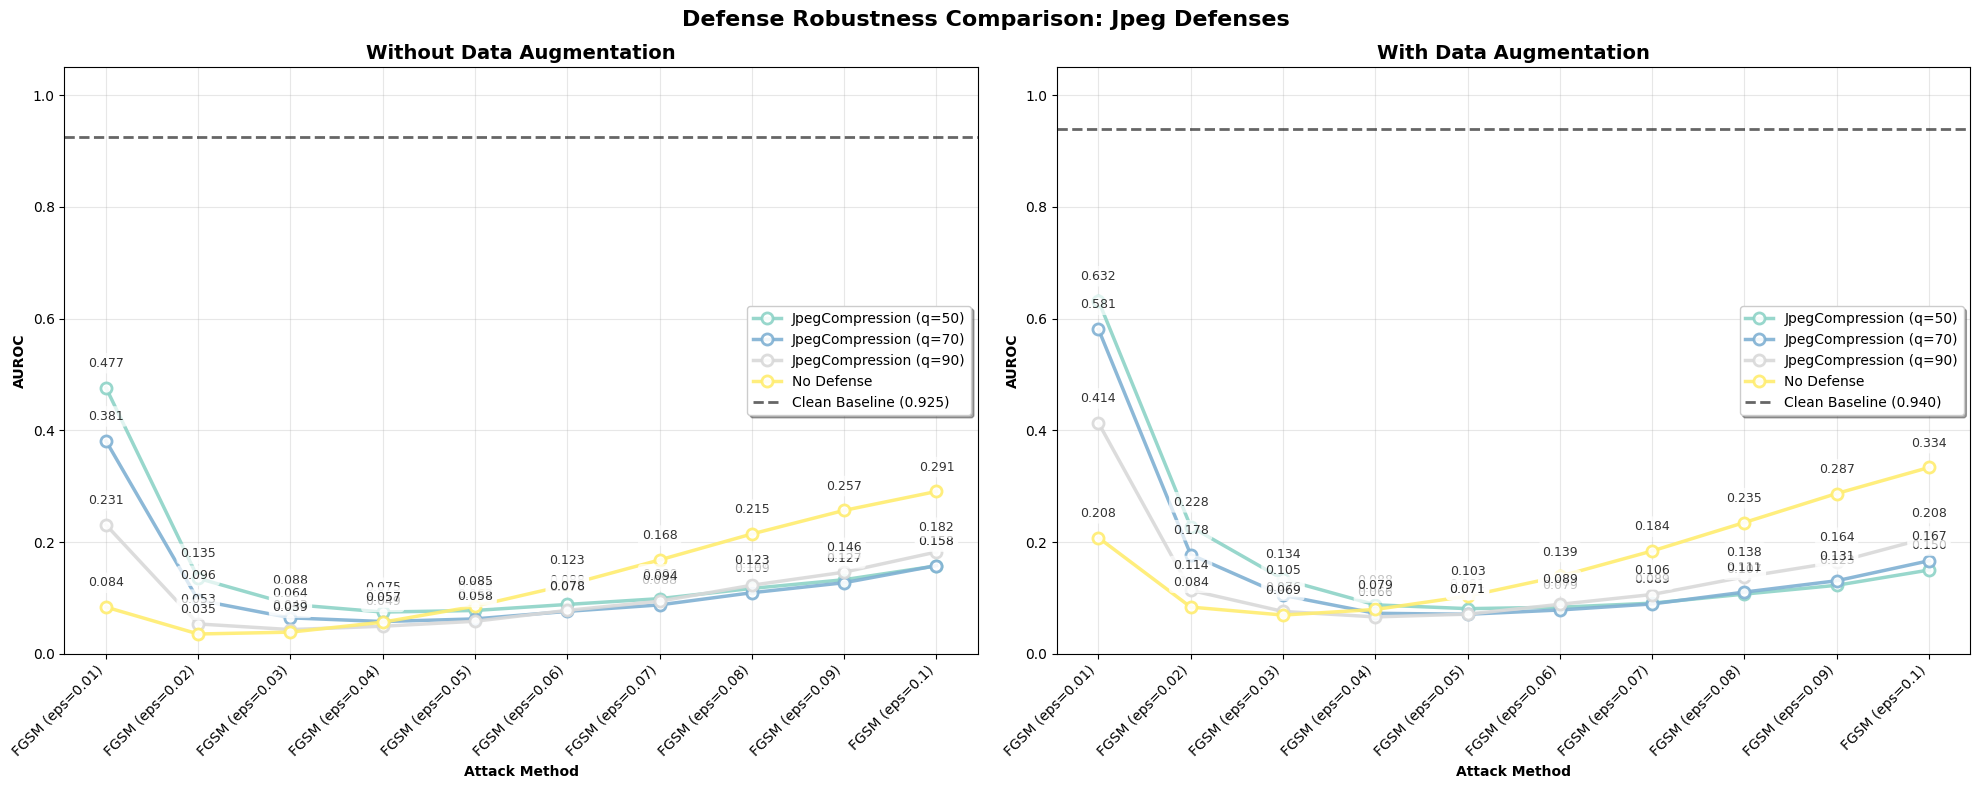

Saved publication-quality figures: ../img/comparison/pgd/augmentation_comparison_Jpeg.[png]


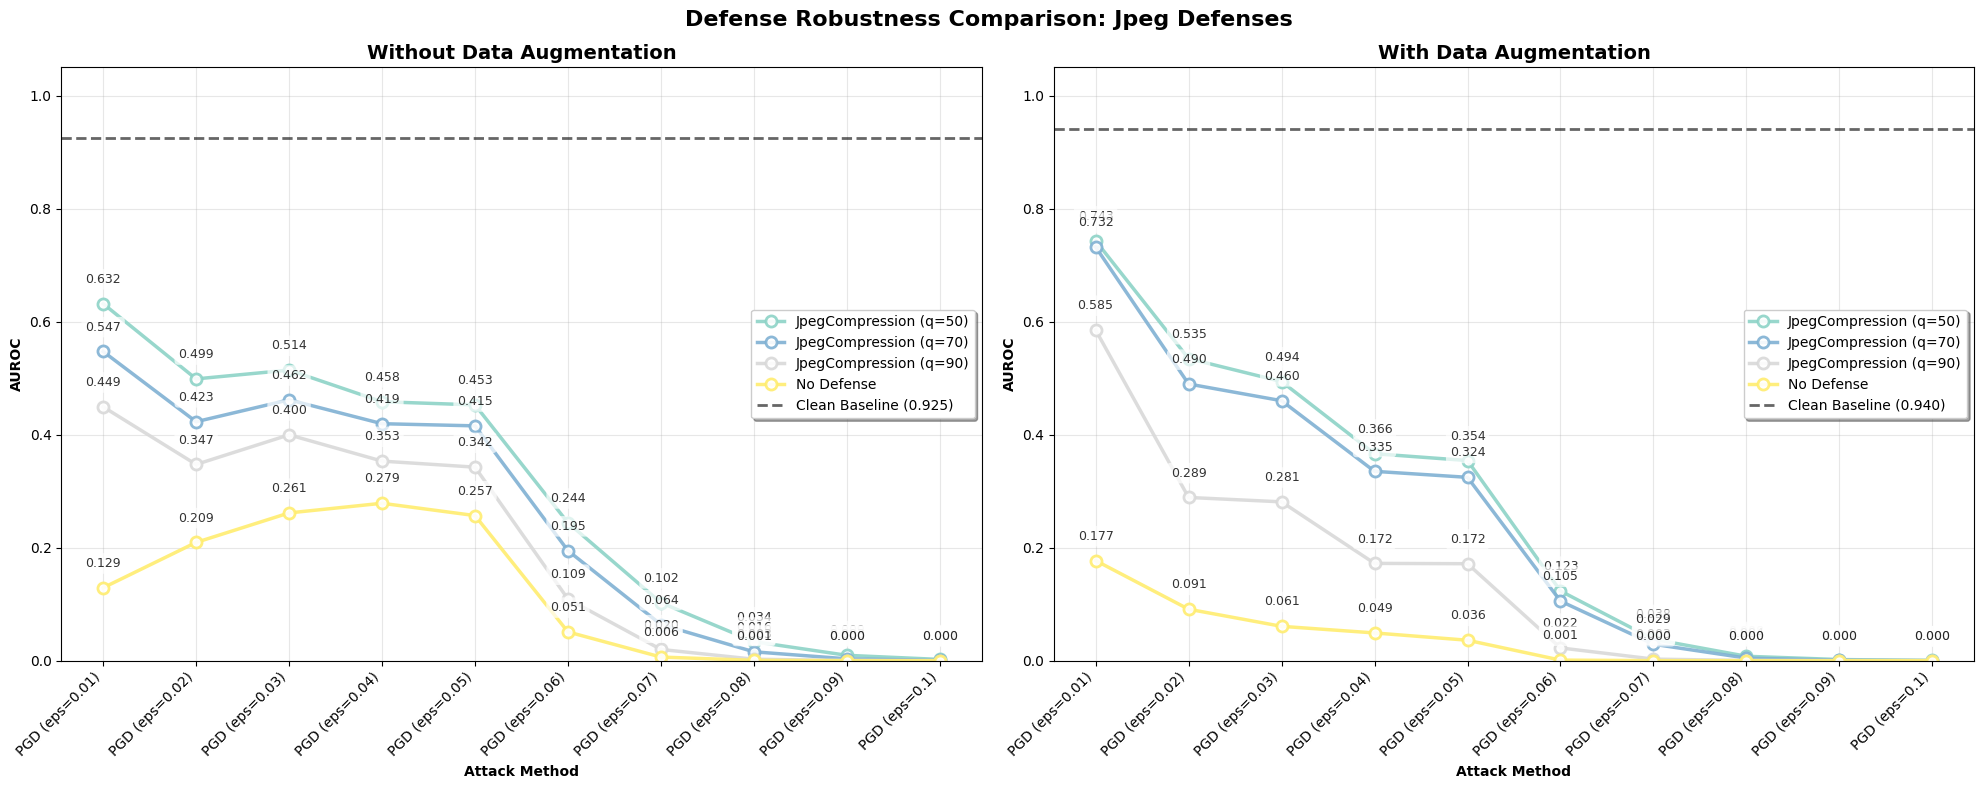

In [ ]:
# Compare specific defense types
plot_augmentation_comparison(results_fgsm_no_aug, results_fgsm_aug, 
                           save_fig=True, metric='AUROC', defence_name='Gaussian', 
                           folder="../img/comparison/fgsm")

plot_augmentation_comparison(results_pgd_no_aug, results_pgd_aug, 
                           save_fig=True, metric='AUROC', defence_name='Gaussian', 
                           folder="../img/comparison/pgd")

plot_augmentation_comparison(results_fgsm_no_aug, results_fgsm_aug, 
                           save_fig=True, metric='AUROC', defence_name='Spatial', 
                           folder="../img/comparison/fgsm")

plot_augmentation_comparison(results_pgd_no_aug, results_pgd_aug, 
                           save_fig=True, metric='AUROC', defence_name='Spatial', 
                           folder="../img/comparison/pgd")

plot_augmentation_comparison(results_fgsm_no_aug, results_fgsm_aug, 
                           save_fig=True, metric='AUROC', defence_name='Variance', 
                           folder="../img/comparison/fgsm")

plot_augmentation_comparison(results_pgd_no_aug, results_pgd_aug, 
                           save_fig=True, metric='AUROC', defence_name='Variance', 
                           folder="../img/comparison/pgd")

plot_augmentation_comparison(results_fgsm_no_aug, results_fgsm_aug, 
                           save_fig=True, metric='AUROC', defence_name='Jpeg', 
                           folder="../img/comparison/fgsm")

plot_augmentation_comparison(results_pgd_no_aug, results_pgd_aug, 
                           save_fig=True, metric='AUROC', defence_name='Jpeg', 
                           folder="../img/comparison/pgd")

Here instead we plot the heatmap for the model with and without augmentation. Again, this is to compare the performance of the model on the attacked images with and without augmentation but here it is reported in a concise way as a heatmap so the reader can easily see the differences in all the attacks and defenses.

In [44]:
def plot_augmentation_heatmap_comparison(df_no_aug: pd.DataFrame, df_aug: pd.DataFrame,
                                       save_fig: bool = True, metric: str = 'AUROC', 
                                       folder: str = "img/comparison"):
    """
    Plot side-by-side heatmap comparison of defense performance with and without data augmentation.
    """
    
    # Create pivot tables
    pivot_no_aug = df_no_aug.pivot(index='attack', columns='defense', values='metric')
    pivot_aug = df_aug.pivot(index='attack', columns='defense', values='metric')
    
    # Get common attacks and defenses
    common_attacks = sorted(set(pivot_no_aug.index).intersection(set(pivot_aug.index)))
    common_defenses = sorted(set(pivot_no_aug.columns).intersection(set(pivot_aug.columns)))
    
    # Filter to common attacks and defenses
    pivot_no_aug = pivot_no_aug.loc[common_attacks, common_defenses]
    pivot_aug = pivot_aug.loc[common_attacks, common_defenses]
    
    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot without augmentation (left subplot)
    mask_no_aug = pivot_no_aug.isnull()
    sns.heatmap(pivot_no_aug, 
                annot=True, 
                fmt='.3f',
                cmap='YlGn',
                center=0.5,
                square=False,
                linewidths=0.5,
                linecolor='white',
                cbar_kws={
                    'label': f'{metric.upper()}',
                    'shrink': 0.8,
                    'aspect': 20
                },
                ax=ax1,
                mask=mask_no_aug,
                vmin=0, vmax=1)  # Ensure same scale
    
    ax1.set_title('Without Data Augmentation', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Defense Method', fontweight='bold')
    ax1.set_ylabel('Attack Method', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.tick_params(axis='y', rotation=0)
    
    # Plot with augmentation (right subplot)
    mask_aug = pivot_aug.isnull()
    sns.heatmap(pivot_aug, 
                annot=True, 
                fmt='.3f',
                cmap='YlGn',
                center=0.5,
                square=False,
                linewidths=0.5,
                linecolor='white',
                cbar_kws={
                    'label': f'{metric.upper()}',
                    'shrink': 0.8,
                    'aspect': 20
                },
                ax=ax2,
                mask=mask_aug,
                vmin=0, vmax=1)  # Ensure same scale
    
    ax2.set_title('With Data Augmentation', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Defense Method', fontweight='bold')
    ax2.set_ylabel('Attack Method', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.tick_params(axis='y', rotation=0)
    
    # Add overall title
    fig.suptitle('Defense Effectiveness: Data Augmentation Impact', 
                fontweight='bold', fontsize=16, y=0.98)
    
    plt.tight_layout()
    
    if save_fig:
        save_figure(fig, "augmentation_heatmap_comparison", folder=folder)
    plt.show()

Saved publication-quality figures: ../img/comparison/fgsm/augmentation_heatmap_comparison.[png]


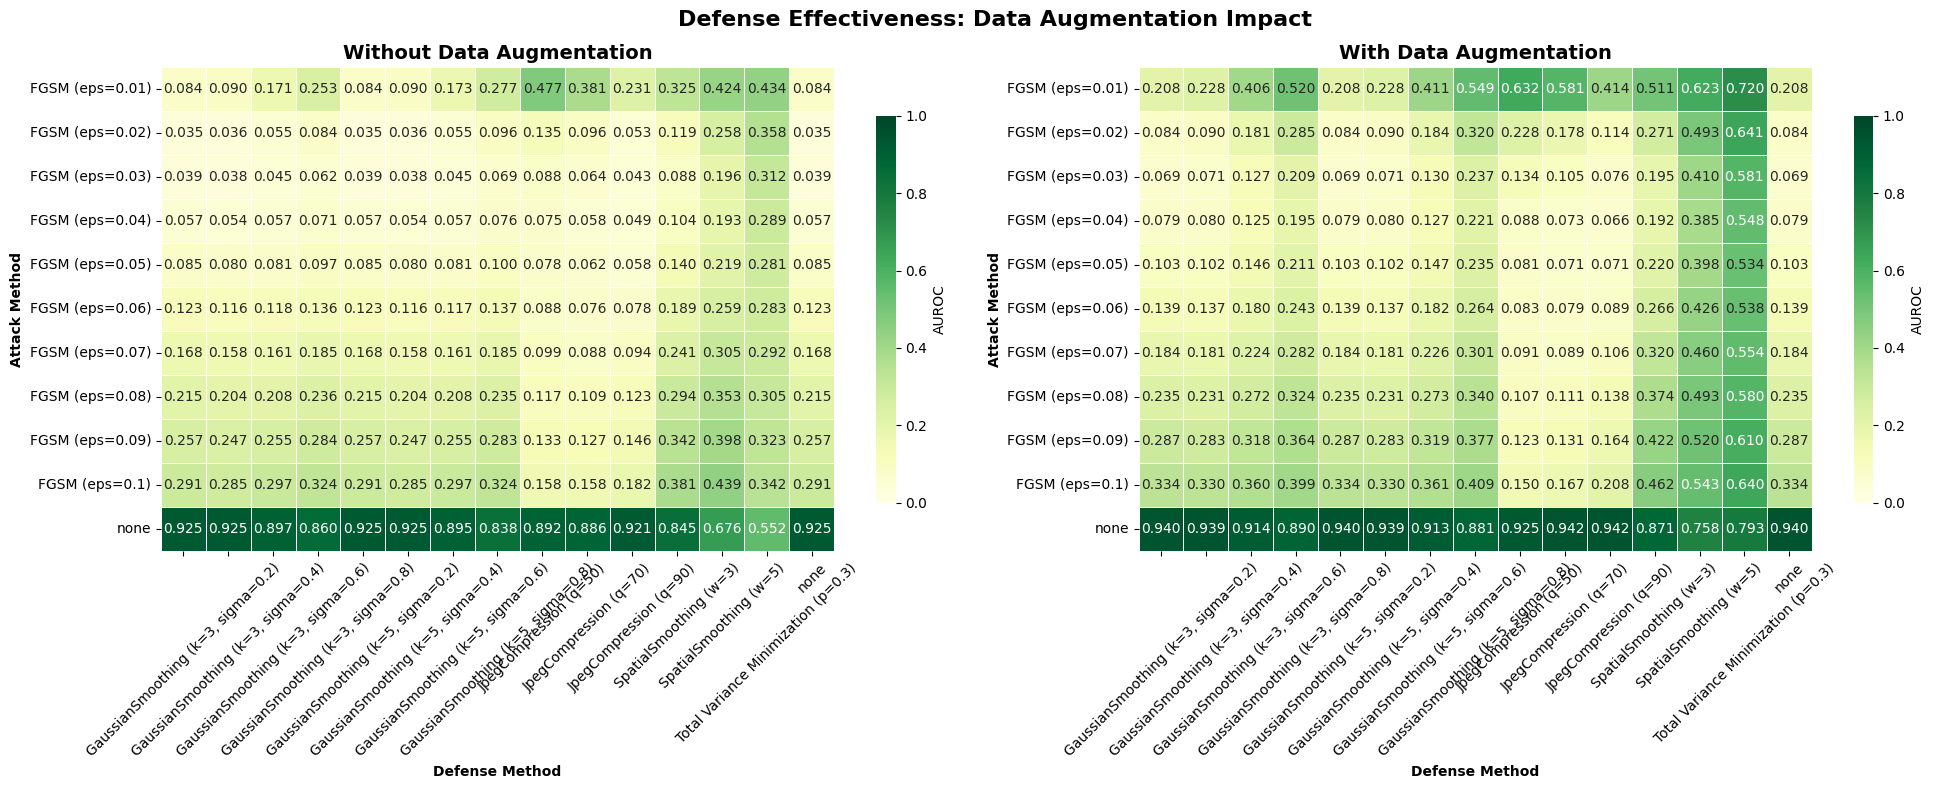

Saved publication-quality figures: ../img/comparison/pgd/augmentation_heatmap_comparison.[png]


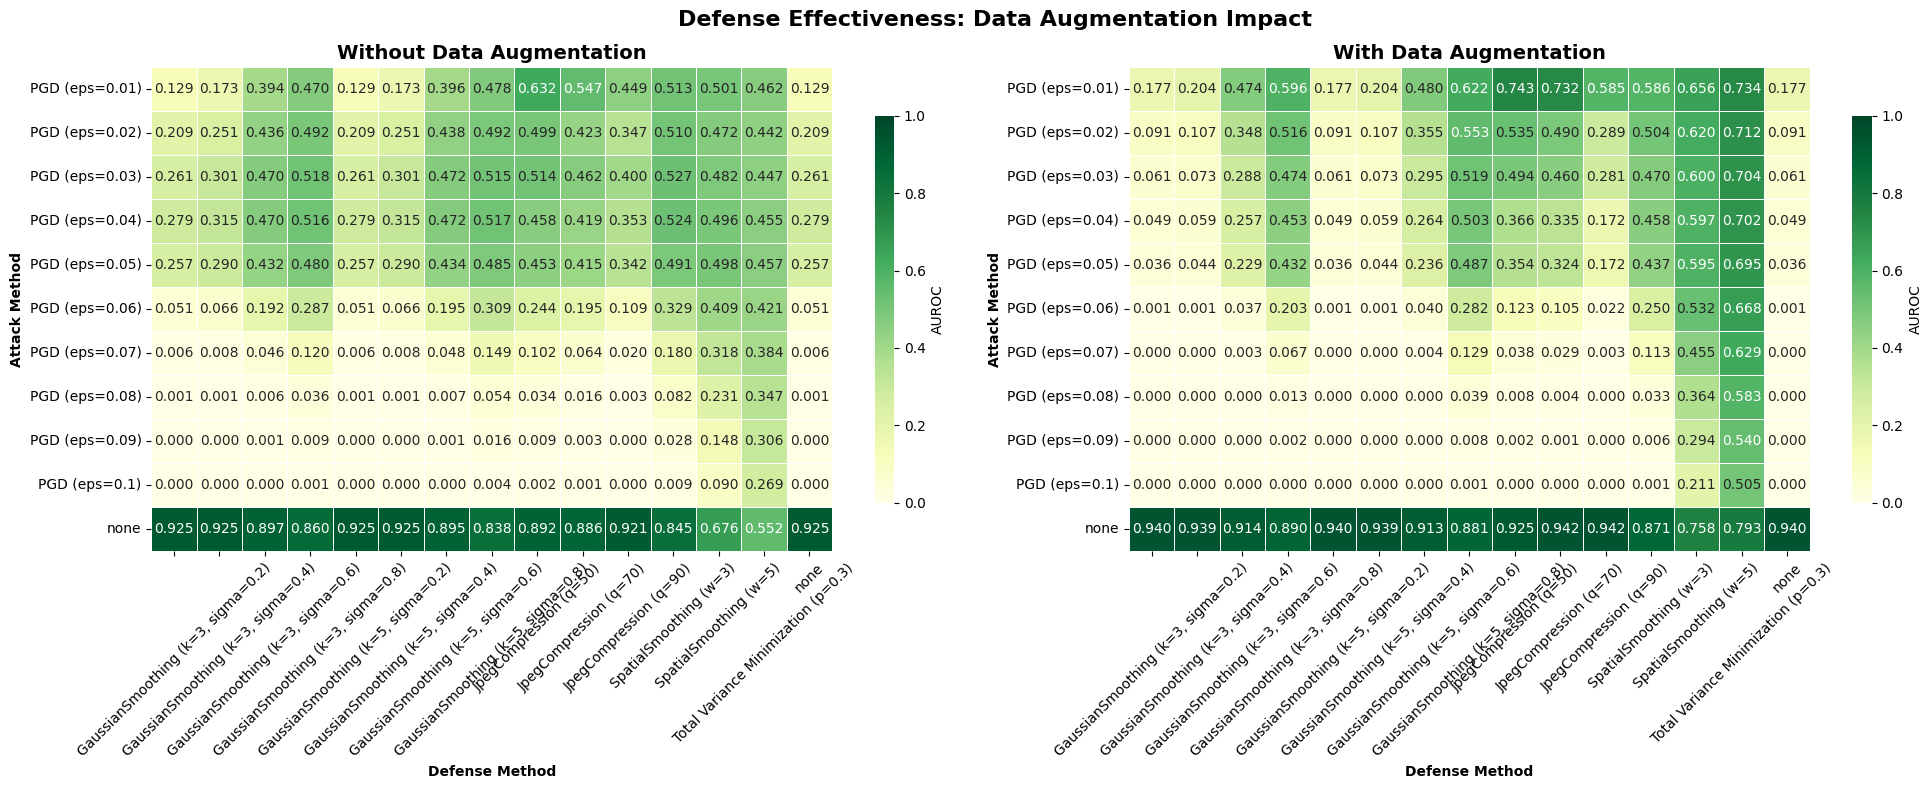

In [47]:
# Heatmap comparisons
plot_augmentation_heatmap_comparison(results_fgsm_no_aug, results_fgsm_aug,
                                   save_fig=True, metric='AUROC', 
                                   folder="../img/comparison/fgsm")

plot_augmentation_heatmap_comparison(results_pgd_no_aug, results_pgd_aug,
                                   save_fig=True, metric='AUROC', 
                                   folder="../img/comparison/pgd")

Here a more in-depth analysis which highlights the positve or negative contribution of the augmentation on the model's performance against adversarial attacks. The analysis will be based on the AUROC of the model on the attacked images with and without augmentation, and we will highlight the differences in performance for each attack type and defense method showing the effectiveness as a coefficient of improvement or degradation.

In [ ]:
def plot_augmentation_difference_analysis(df_no_aug: pd.DataFrame, df_aug: pd.DataFrame,
                                        save_fig: bool = True, metric: str = 'AUROC', 
                                        folder: str = "img/comparison"):
    """
    Plot the difference in performance between augmented and non-augmented models.
    """
    
    # Create pivot tables
    pivot_no_aug = df_no_aug.pivot(index='attack', columns='defense', values='metric')
    pivot_aug = df_aug.pivot(index='attack', columns='defense', values='metric')
    
    # Get common attacks and defenses
    common_attacks = sorted(set(pivot_no_aug.index).intersection(set(pivot_aug.index)))
    common_defenses = sorted(set(pivot_no_aug.columns).intersection(set(pivot_aug.columns)))
    
    # Filter to common attacks and defenses and calculate difference
    pivot_no_aug = pivot_no_aug.loc[common_attacks, common_defenses]
    pivot_aug = pivot_aug.loc[common_attacks, common_defenses]
    pivot_diff = pivot_aug - pivot_no_aug
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot difference heatmap
    mask = pivot_diff.isnull()
    sns.heatmap(pivot_diff, 
                annot=True, 
                fmt='+.3f',
                cmap='RdYlGn',
                center=0,
                square=False,
                linewidths=0.5,
                linecolor='white',
                cbar_kws={
                    'label': f'{metric.upper()} Improvement',
                    'shrink': 0.8,
                    'aspect': 20
                },
                ax=ax,
                mask=mask)
    
    ax.set_title('Data Augmentation Impact\n(Positive = Improvement, Negative = Degradation)', 
                fontweight='bold', fontsize=14)
    ax.set_xlabel('Defense Method', fontweight='bold')
    ax.set_ylabel('Attack Method', fontweight='bold')
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    if save_fig:
        save_figure(fig, "augmentation_difference_analysis", folder=folder)
    plt.show()

Saved publication-quality figures: ../img/comparison/fgsm/augmentation_difference_analysis.[png]


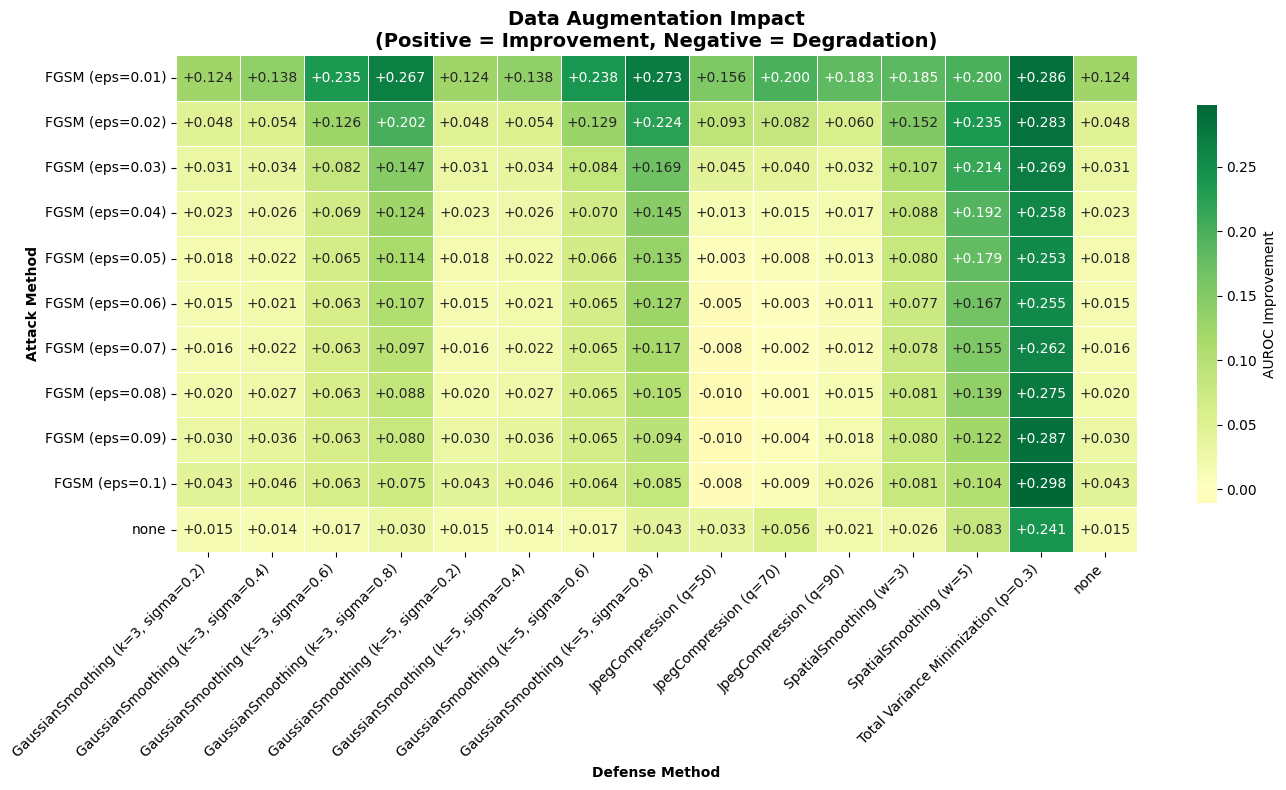

Saved publication-quality figures: ../img/comparison/pgd/augmentation_difference_analysis.[png]


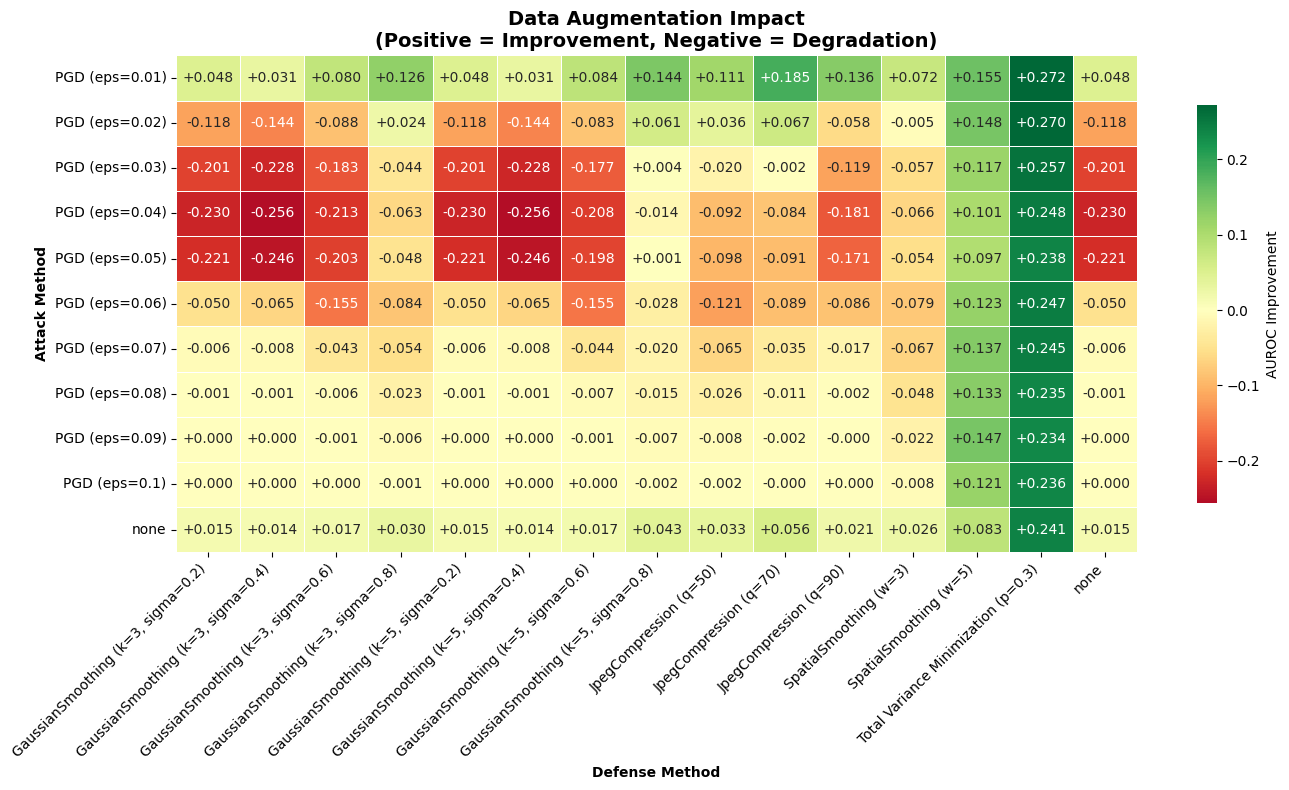

In [48]:
# Difference analysis
plot_augmentation_difference_analysis(results_fgsm_no_aug, results_fgsm_aug,
                                    save_fig=True, metric='AUROC', 
                                    folder="../img/comparison/fgsm")

plot_augmentation_difference_analysis(results_pgd_no_aug, results_pgd_aug,
                                    save_fig=True, metric='AUROC', 
                                    folder="../img/comparison/pgd")

So far we analyzed the overall performance of the model, here we focus on each of the defense compared to the baseline.

In [49]:
def plot_defense_configuration_baseline_comparison_individual(df_no_aug: pd.DataFrame, df_aug: pd.DataFrame,
                                                            defense_type: str, save_fig: bool = True, 
                                                            metric: str = 'AUROC', 
                                                            folder: str = "img/defense_baseline_comparison"):
    """
    Plot side-by-side comparison for a specific defense type baseline performance 
    with and without data augmentation.
    """
    
    # Filter for no attack scenarios and specific defense type
    clean_defense_no_aug = df_no_aug[(df_no_aug['attack'] == 'none') & 
                                     (df_no_aug['defense'] != 'none') & 
                                     (df_no_aug['defense'].str.startswith(defense_type))].copy()
    clean_defense_aug = df_aug[(df_aug['attack'] == 'none') & 
                              (df_aug['defense'] != 'none') & 
                              (df_aug['defense'].str.startswith(defense_type))].copy()
    
    clean_baseline_no_aug = df_no_aug[(df_no_aug['attack'] == 'none') & (df_no_aug['defense'] == 'none')]['metric'].values[0]
    clean_baseline_aug = df_aug[(df_aug['attack'] == 'none') & (df_aug['defense'] == 'none')]['metric'].values[0]
    
    if clean_defense_no_aug.empty or clean_defense_aug.empty:
        print(f"No defense-only data found for {defense_type} in one or both datasets")
        return
    
    # Get common defenses for this type
    defenses_no_aug = set(clean_defense_no_aug['defense'].unique())
    defenses_aug = set(clean_defense_aug['defense'].unique())
    common_defenses = sorted(defenses_no_aug.intersection(defenses_aug))
    
    if not common_defenses:
        print(f"No common defenses found for {defense_type}")
        return
    
    # Sort defenses by configuration parameter
    def extract_param(defense_name):
        try:
            if '=' in defense_name:
                param_str = defense_name.split('=')[1].rstrip(')')
                return float(param_str)
            elif '(' in defense_name and ')' in defense_name:
                param_str = defense_name.split('(')[1].split(')')[0]
                if param_str.replace('.', '').isdigit():
                    return float(param_str)
            return 0
        except:
            return 0
    
    sorted_defenses = sorted(common_defenses, key=extract_param)
    
    # Create side-by-side subplots
    fig, (ax_no_aug, ax_aug) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(sorted_defenses)))
    
    # Get metrics for each configuration
    metrics_no_aug = []
    metrics_aug = []
    labels = []
    
    for defense in sorted_defenses:
        # No augmentation metrics
        metric_val_no_aug = clean_defense_no_aug[clean_defense_no_aug['defense'] == defense]['metric'].values
        # Augmentation metrics
        metric_val_aug = clean_defense_aug[clean_defense_aug['defense'] == defense]['metric'].values
        
        if len(metric_val_no_aug) > 0 and len(metric_val_aug) > 0:
            metrics_no_aug.append(metric_val_no_aug[0])
            metrics_aug.append(metric_val_aug[0])
            
            # Create clean label
            if '(' in defense and ')' in defense:
                param_part = defense.split('(')[1].split(')')[0]
                labels.append(param_part)
            else:
                labels.append(defense.replace(defense_type, '').strip())
    
    if not metrics_no_aug or not metrics_aug:
        print(f"No matching data for {defense_type}")
        return
    
    # Plot without augmentation (left)
    x_pos = range(len(metrics_no_aug))
    bars_no_aug = ax_no_aug.bar(x_pos, metrics_no_aug, color=colors[:len(metrics_no_aug)], 
                               alpha=0.8, edgecolor='white', linewidth=1.5)
    
    ax_no_aug.axhline(y=clean_baseline_no_aug, color='red', linestyle='--', alpha=0.7, linewidth=2,
                     label=f'No Defense ({clean_baseline_no_aug:.3f})')
    
    for i, (bar, metric_val) in enumerate(zip(bars_no_aug, metrics_no_aug)):
        height = bar.get_height()
        ax_no_aug.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{metric_val:.3f}',
                      ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax_no_aug.set_xlabel('Configuration', fontweight='bold')
    ax_no_aug.set_ylabel(f'{metric.upper()}', fontweight='bold')
    ax_no_aug.set_title(f'Without Data Augmentation', fontweight='bold', fontsize=14)
    ax_no_aug.set_xticks(x_pos)
    ax_no_aug.set_xticklabels(labels, rotation=45, ha='right')
    ax_no_aug.set_ylim(0, 1.05)
    ax_no_aug.grid(True, alpha=0.3, axis='y')
    ax_no_aug.legend()
    
    # Plot with augmentation (right)
    bars_aug = ax_aug.bar(x_pos, metrics_aug, color=colors[:len(metrics_aug)], 
                         alpha=0.8, edgecolor='white', linewidth=1.5)
    
    ax_aug.axhline(y=clean_baseline_aug, color='red', linestyle='--', alpha=0.7, linewidth=2,
                  label=f'No Defense ({clean_baseline_aug:.3f})')
    
    for i, (bar, metric_val) in enumerate(zip(bars_aug, metrics_aug)):
        height = bar.get_height()
        ax_aug.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{metric_val:.3f}',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax_aug.set_xlabel('Configuration', fontweight='bold')
    ax_aug.set_title(f'With Data Augmentation', fontweight='bold', fontsize=14)
    ax_aug.set_xticks(x_pos)
    ax_aug.set_xticklabels(labels, rotation=45, ha='right')
    ax_aug.set_ylim(0, 1.05)
    ax_aug.grid(True, alpha=0.3, axis='y')
    ax_aug.legend()
    
    plt.tight_layout()
    
    if save_fig:
        safe_defense_name = defense_type.replace(' ', '_').replace('(', '').replace(')', '').lower()
        save_figure(fig, f"baseline_comparison_{safe_defense_name}", folder=folder)
    plt.show()


def plot_all_defense_baseline_comparisons_individual(df_no_aug: pd.DataFrame, df_aug: pd.DataFrame,
                                                   save_fig: bool = True, metric: str = 'AUROC', 
                                                   folder: str = "img/defense_baseline_comparison"):
    """
    Create individual side-by-side comparison plots for each defense type.
    """
    
    # Get all defense types from both datasets
    clean_defense_no_aug = df_no_aug[(df_no_aug['attack'] == 'none') & (df_no_aug['defense'] != 'none')].copy()
    clean_defense_aug = df_aug[(df_aug['attack'] == 'none') & (df_aug['defense'] != 'none')].copy()
    
    if clean_defense_no_aug.empty or clean_defense_aug.empty:
        print("No defense-only data found in one or both datasets")
        return
    
    # Get all defense types
    all_defenses = set(clean_defense_no_aug['defense'].unique()).union(
                   set(clean_defense_aug['defense'].unique()))
    
    defense_types = set()
    for defense in all_defenses:
        defense_type = defense.split('(')[0].strip()
        defense_types.add(defense_type)
    
    defense_types = sorted(defense_types)
    
    print(f"Creating individual baseline comparison plots for: {defense_types}")
    
    # Create individual plot for each defense type
    for defense_type in defense_types:
        print(f"Creating plot for {defense_type}...")
        plot_defense_configuration_baseline_comparison_individual(
            df_no_aug, df_aug, defense_type, save_fig, metric, folder)


def plot_defense_baseline_difference_analysis_individual(df_no_aug: pd.DataFrame, df_aug: pd.DataFrame,
                                                       defense_type: str, save_fig: bool = True, 
                                                       metric: str = 'AUROC', 
                                                       folder: str = "img/defense_baseline_comparison"):
    """
    Plot the difference in baseline performance for a specific defense type.
    """
    
    # Filter for no attack scenarios and specific defense type
    clean_defense_no_aug = df_no_aug[(df_no_aug['attack'] == 'none') & 
                                     (df_no_aug['defense'] != 'none') & 
                                     (df_no_aug['defense'].str.startswith(defense_type))].copy()
    clean_defense_aug = df_aug[(df_aug['attack'] == 'none') & 
                              (df_aug['defense'] != 'none') & 
                              (df_aug['defense'].str.startswith(defense_type))].copy()
    
    # Get common defenses
    defenses_no_aug = set(clean_defense_no_aug['defense'].unique())
    defenses_aug = set(clean_defense_aug['defense'].unique())
    common_defenses = sorted(defenses_no_aug.intersection(defenses_aug))
    
    if not common_defenses:
        print(f"No common defenses found for {defense_type}")
        return
    
    # Calculate differences
    defense_names = []
    differences = []
    
    for defense in common_defenses:
        metric_no_aug = clean_defense_no_aug[clean_defense_no_aug['defense'] == defense]['metric'].values
        metric_aug = clean_defense_aug[clean_defense_aug['defense'] == defense]['metric'].values
        
        if len(metric_no_aug) > 0 and len(metric_aug) > 0:
            diff = metric_aug[0] - metric_no_aug[0]
            differences.append(diff)
            # Create clean name for display
            if '(' in defense and ')' in defense:
                param_part = defense.split('(')[1].split(')')[0]
                defense_names.append(f"{defense_type} ({param_part})")
            else:
                defense_names.append(defense)
    
    if not differences:
        print(f"No data to compare for {defense_type}")
        return
    
    # Sort by difference
    sorted_data = sorted(zip(differences, defense_names), reverse=True)
    sorted_diffs, sorted_names = zip(*sorted_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, max(6, len(sorted_names) * 0.5)))
    
    # Color bars based on positive/negative improvement
    colors = ['green' if diff > 0 else 'red' for diff in sorted_diffs]
    
    bars = ax.barh(range(len(sorted_names)), sorted_diffs, color=colors, alpha=0.7,
                   edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for i, (bar, diff) in enumerate(zip(bars, sorted_diffs)):
        width = bar.get_width()
        ax.text(width + (0.002 if width >= 0 else -0.002), bar.get_y() + bar.get_height()/2, 
               f'{diff:+.3f}',
               ha='left' if width >= 0 else 'right', va='center', fontweight='bold', fontsize=10)
    
    # Add vertical line at zero
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=11)
    ax.set_xlabel(f'{metric.upper()} Difference (With Aug - Without Aug)', fontweight='bold')
    ax.set_title(f'{defense_type} Defense: Data Augmentation Impact on Baseline Performance\n(Green = Improvement, Red = Degradation)', 
                fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add text annotation explaining the interpretation
    textstr = 'Positive values indicate data augmentation improves baseline performance'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    if save_fig:
        safe_defense_name = defense_type.replace(' ', '_').replace('(', '').replace(')', '').lower()
        save_figure(fig, f"baseline_difference_{safe_defense_name}", folder=folder)
    plt.show()

Creating individual baseline comparison plots...
Creating individual baseline comparison plots for: ['GaussianSmoothing', 'JpegCompression', 'SpatialSmoothing', 'Total Variance Minimization']
Creating plot for GaussianSmoothing...
Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_comparison_gaussiansmoothing.[png]


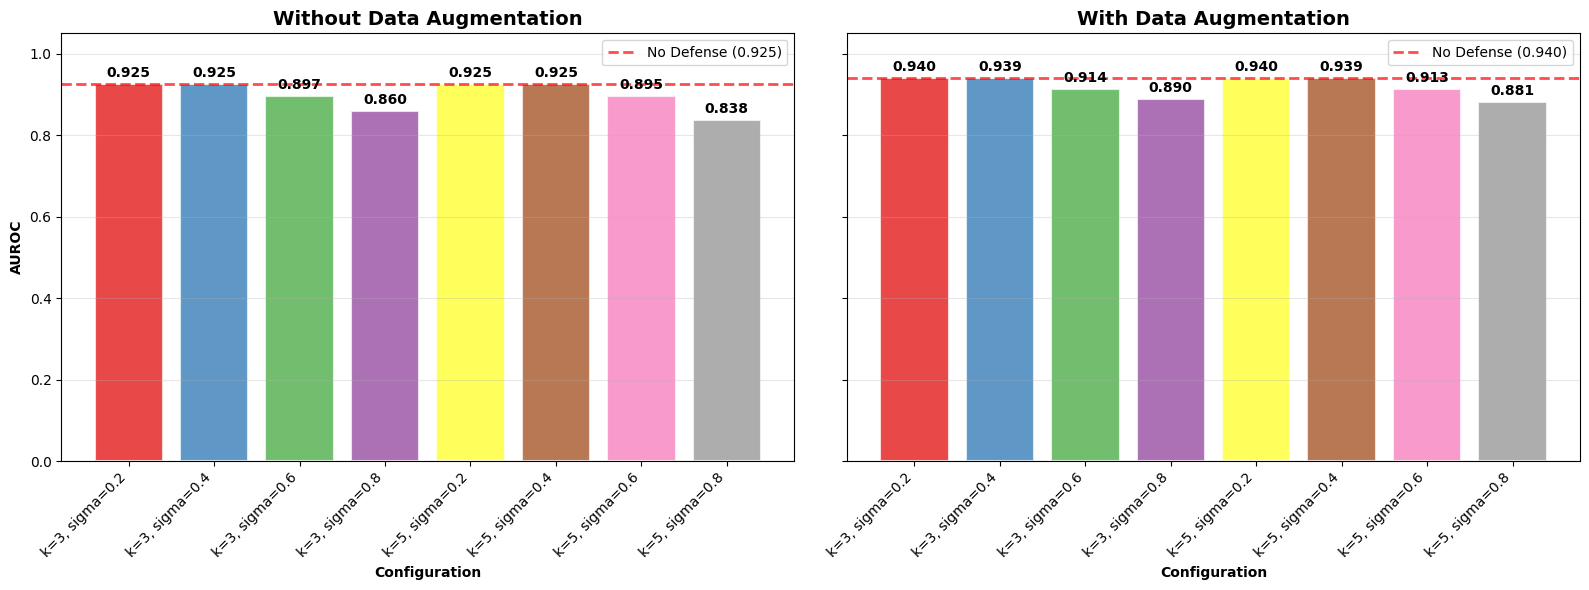

Creating plot for JpegCompression...
Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_comparison_jpegcompression.[png]


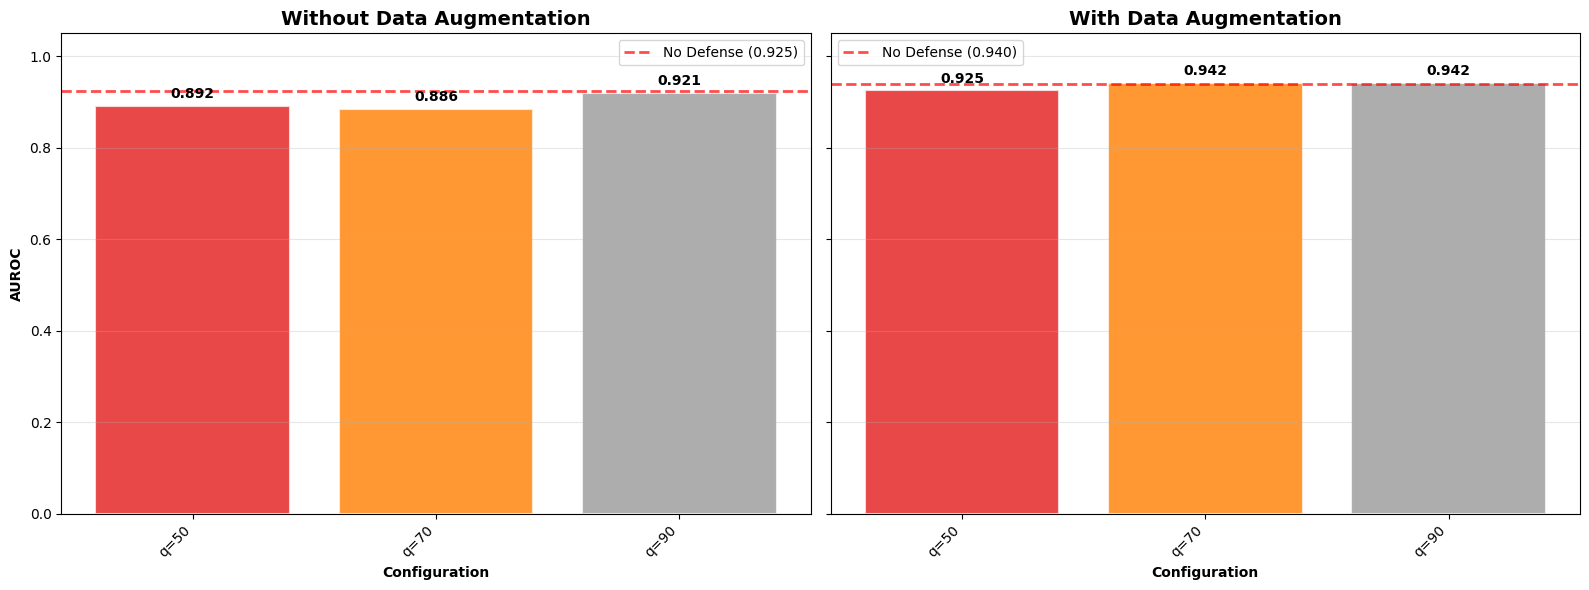

Creating plot for SpatialSmoothing...
Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_comparison_spatialsmoothing.[png]


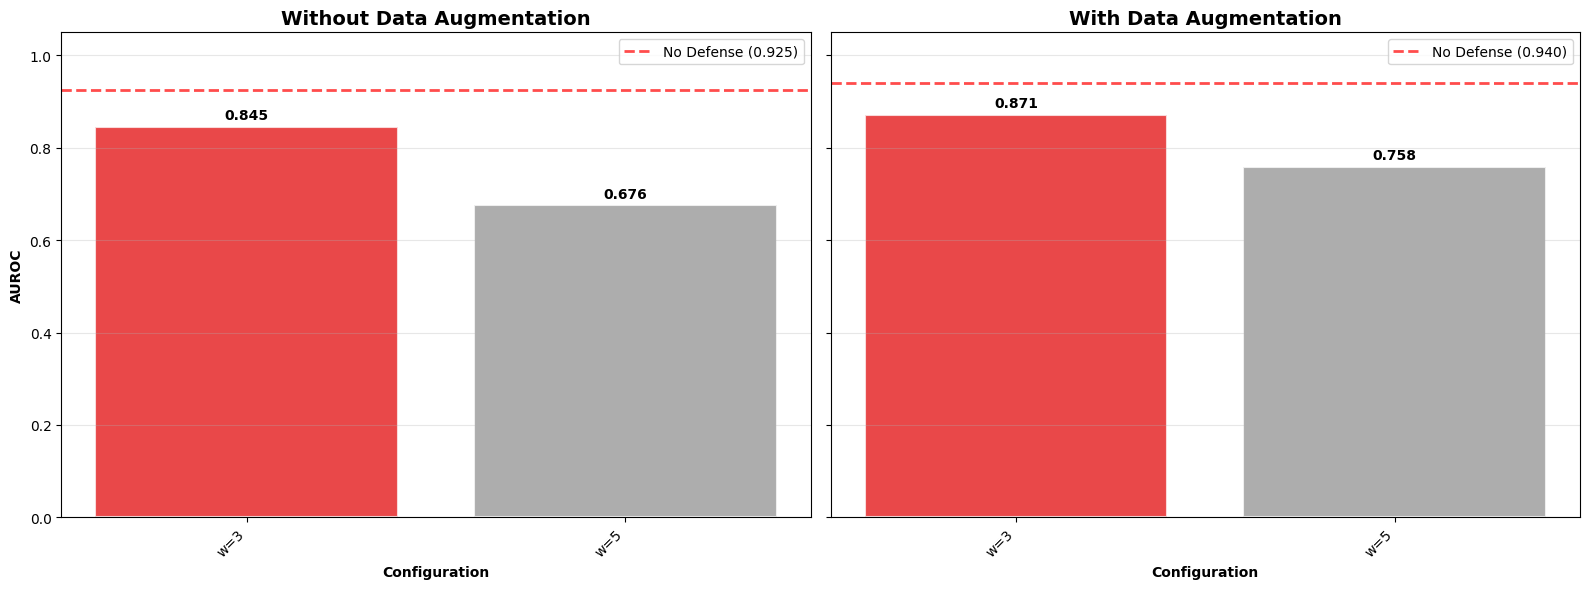

Creating plot for Total Variance Minimization...
Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_comparison_total_variance_minimization.[png]


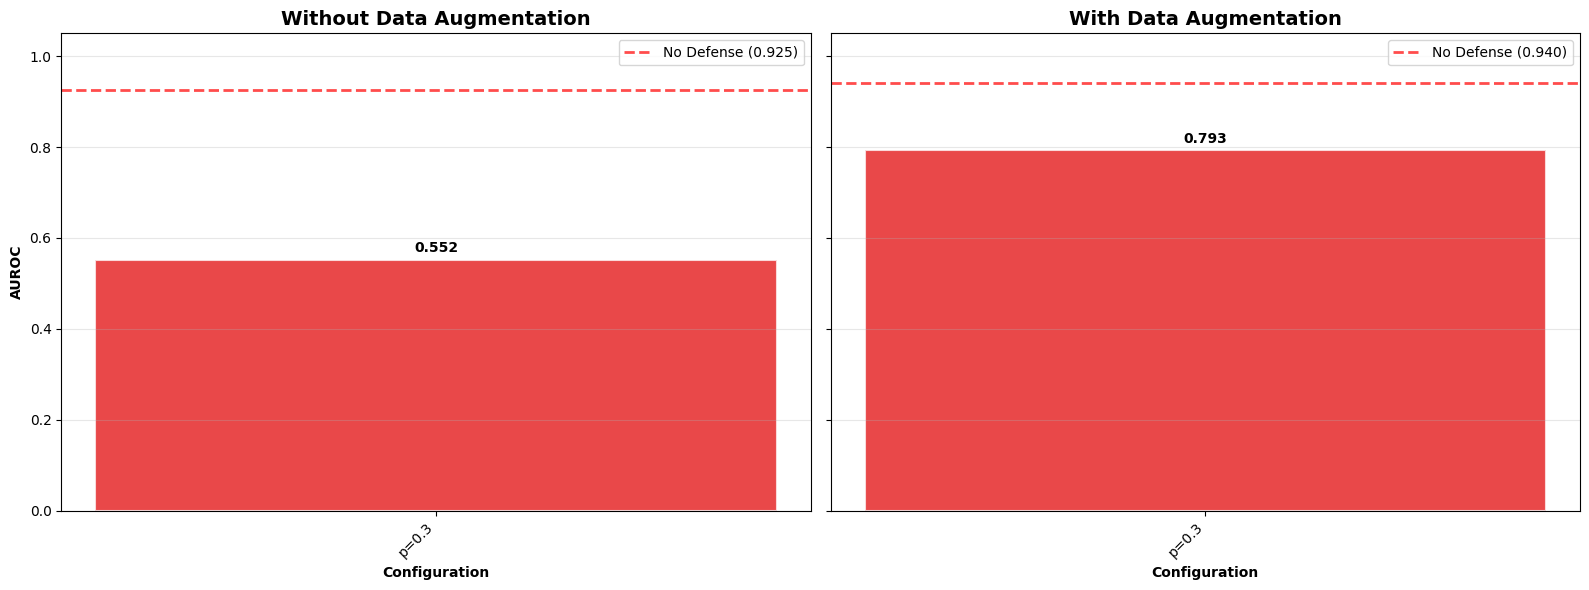

Creating individual baseline comparison plots for: ['GaussianSmoothing', 'JpegCompression', 'SpatialSmoothing', 'Total Variance Minimization']
Creating plot for GaussianSmoothing...
Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_comparison_gaussiansmoothing.[png]


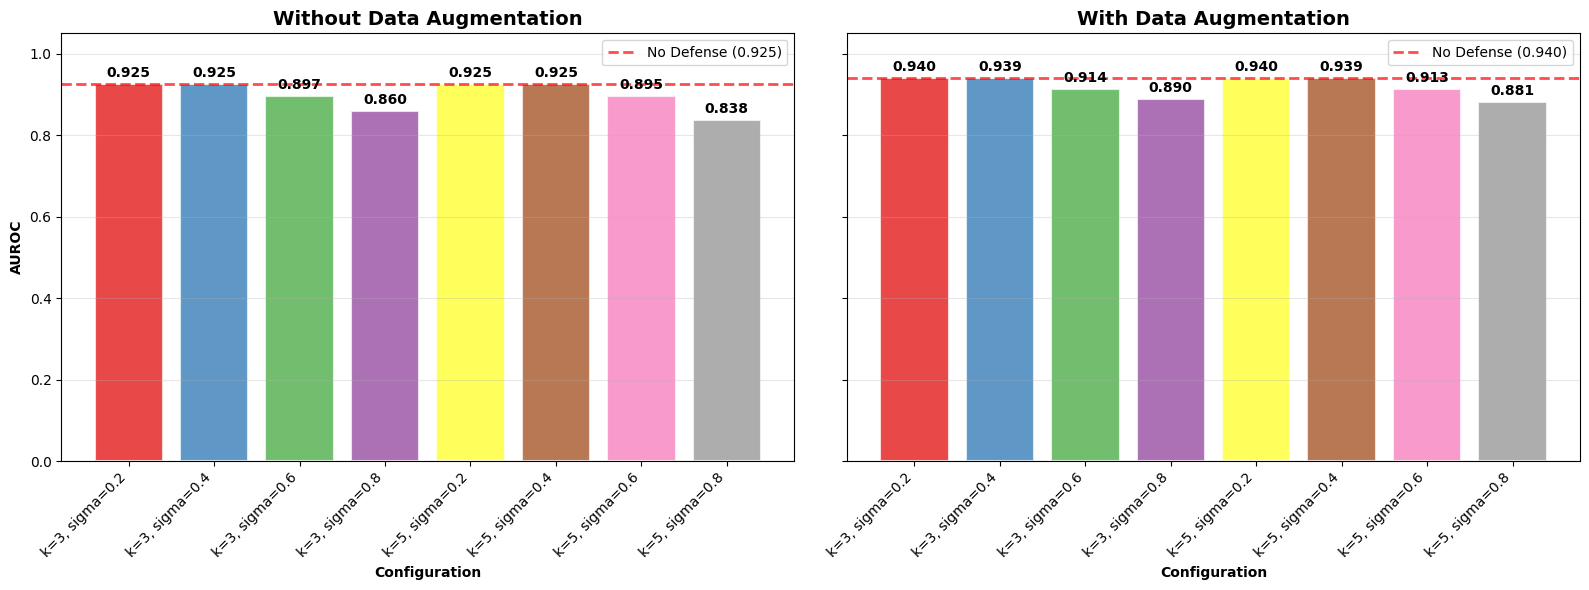

Creating plot for JpegCompression...
Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_comparison_jpegcompression.[png]


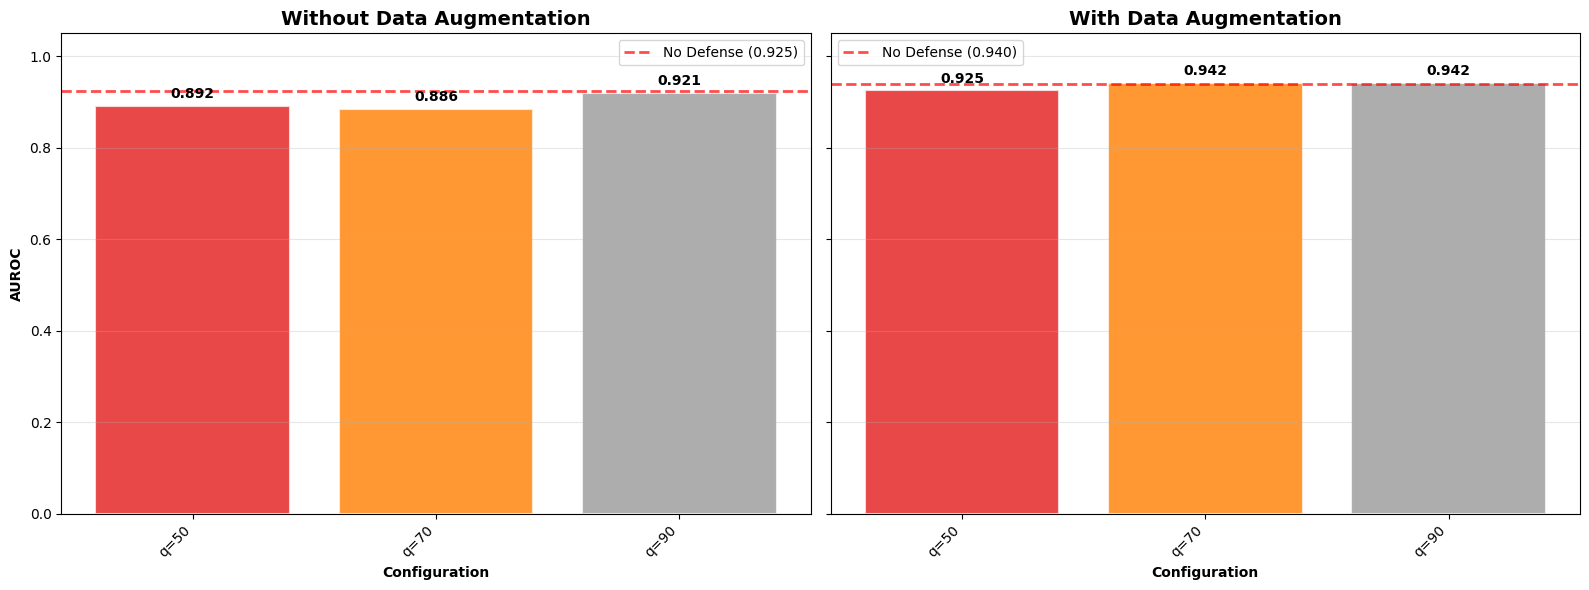

Creating plot for SpatialSmoothing...
Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_comparison_spatialsmoothing.[png]


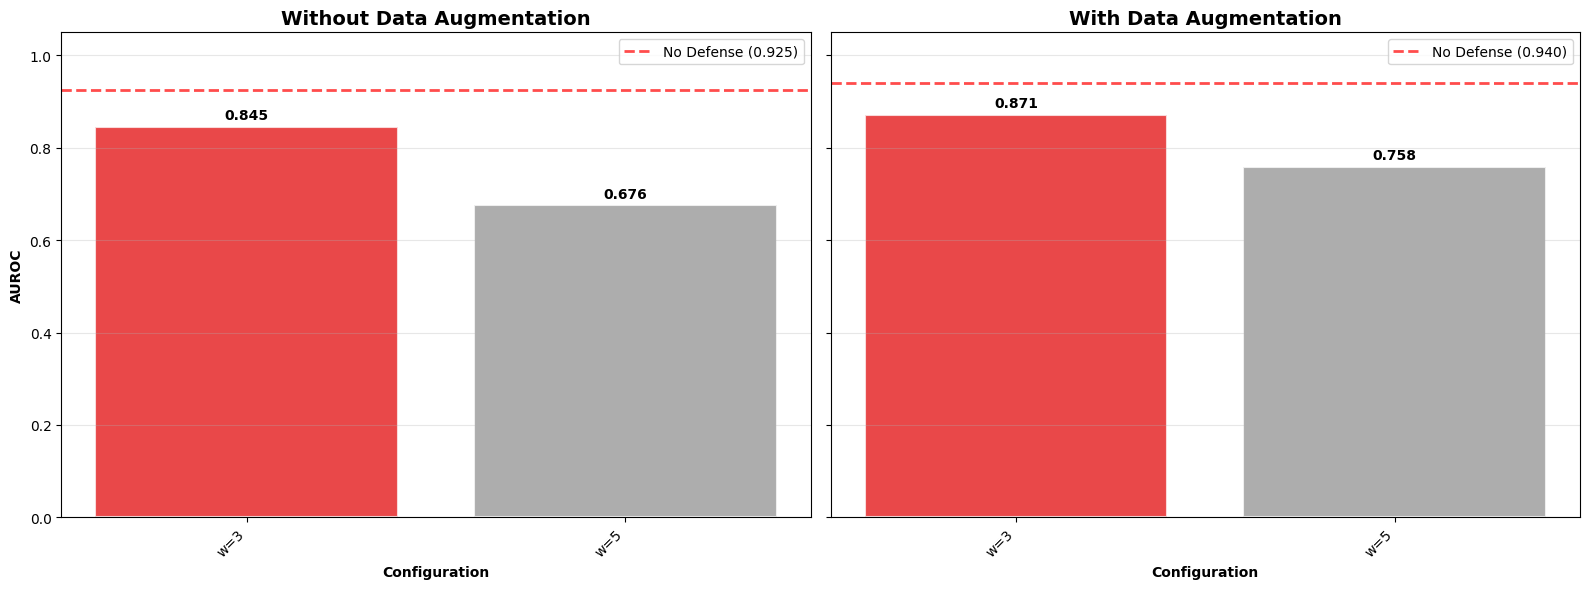

Creating plot for Total Variance Minimization...
Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_comparison_total_variance_minimization.[png]


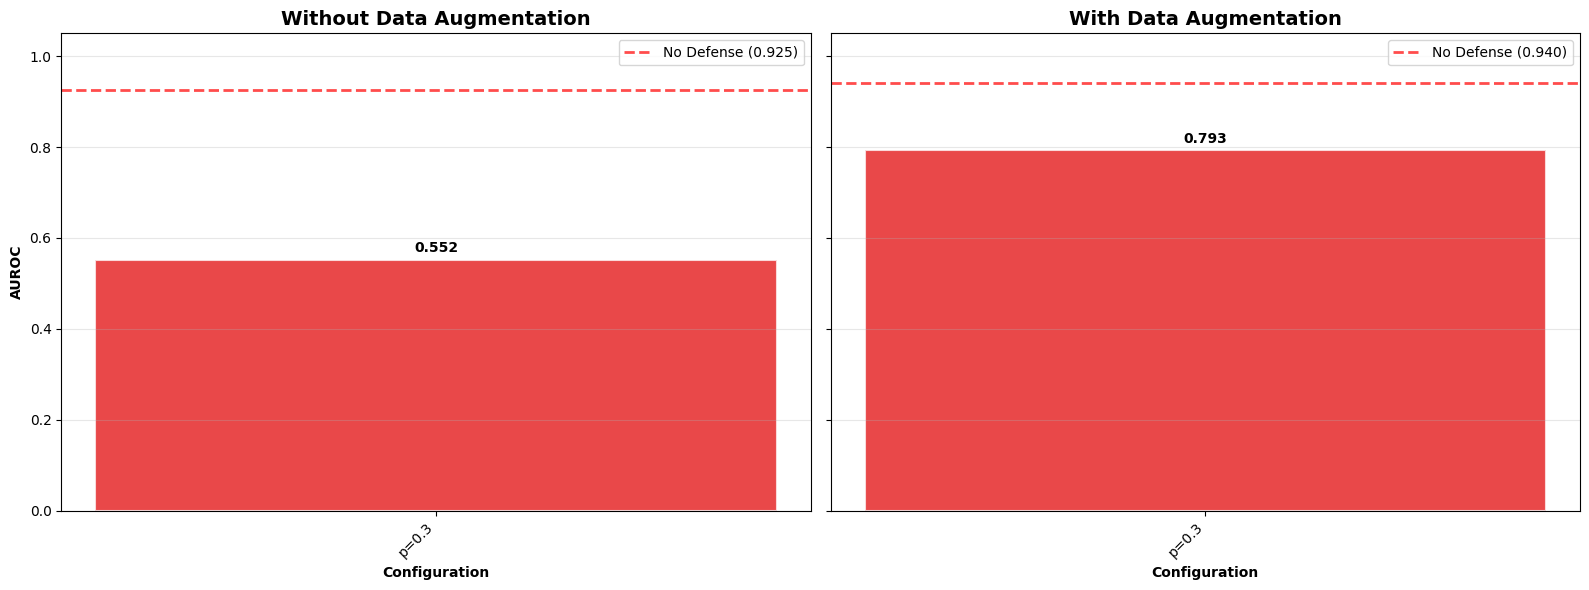

Creating individual difference analysis plots...
Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_difference_gaussian.[png]


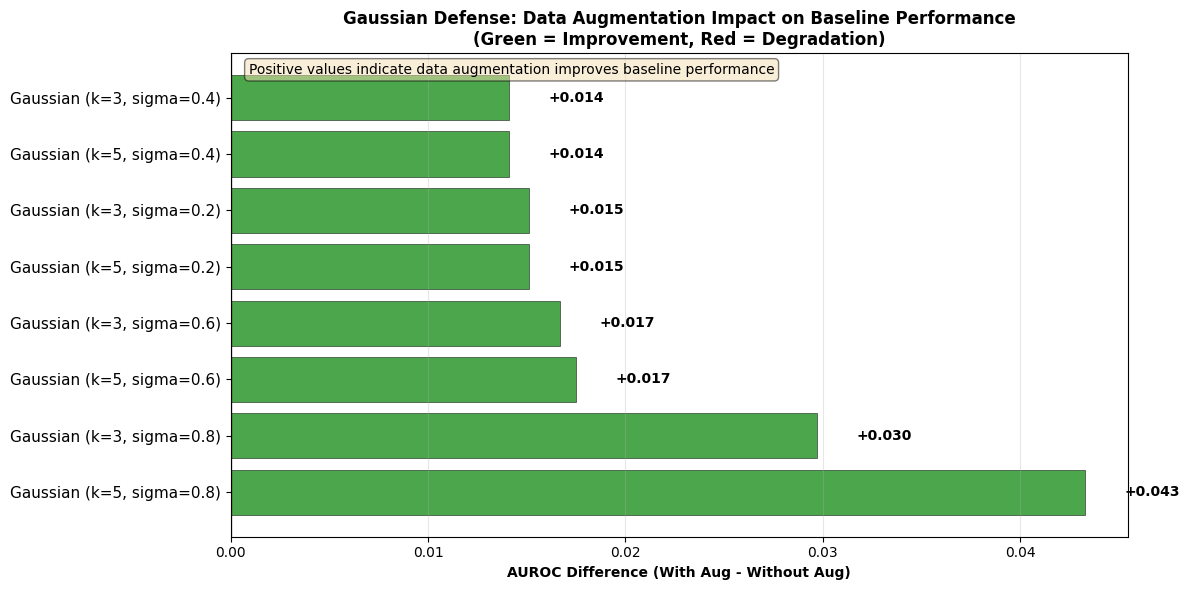

Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_difference_gaussian.[png]


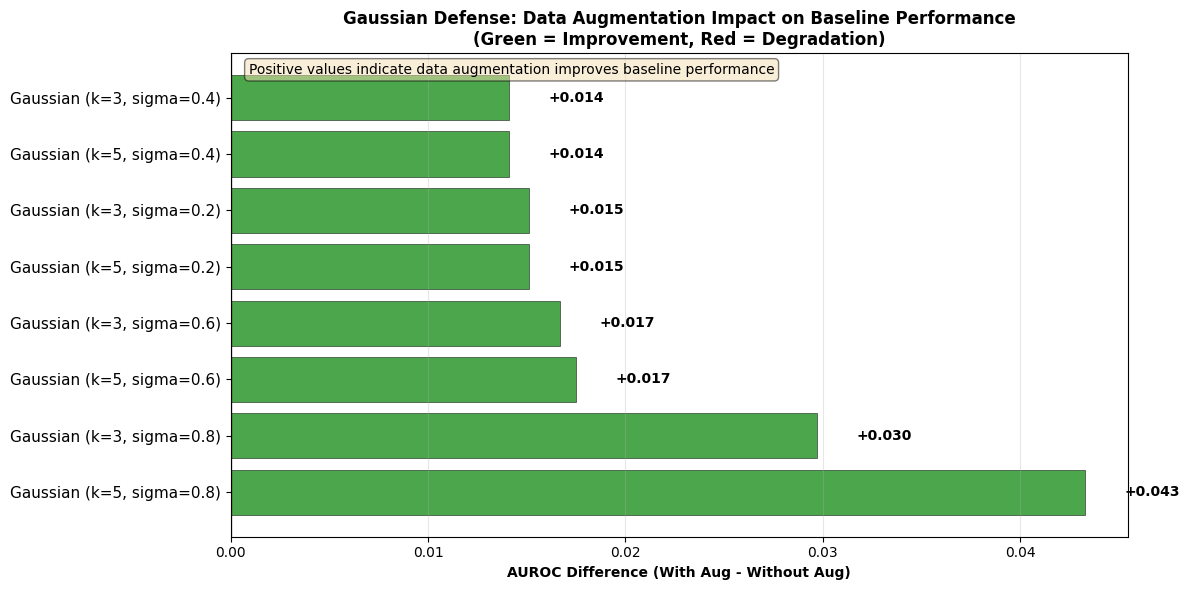

Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_difference_spatial.[png]


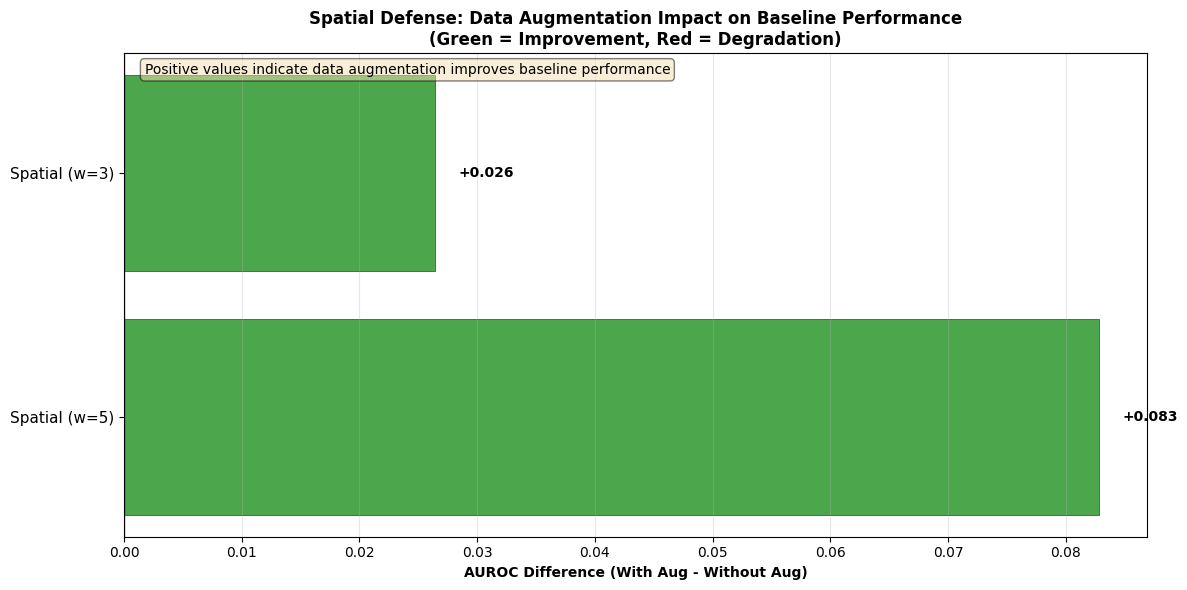

Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_difference_spatial.[png]


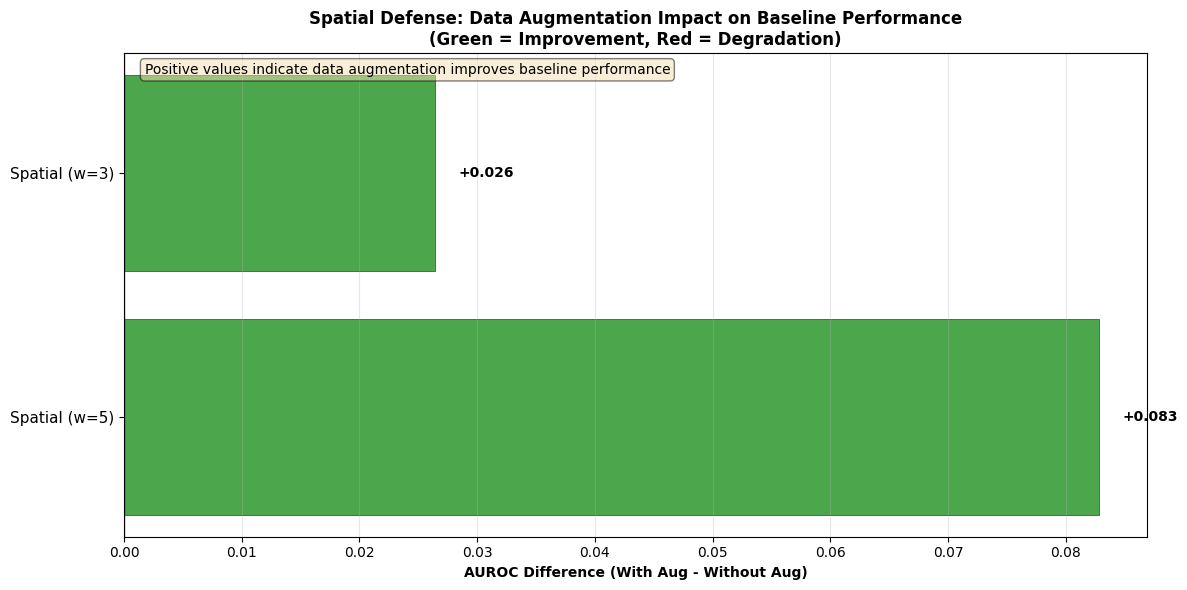

No common defenses found for Variance
No common defenses found for Variance
Saved publication-quality figures: ../img/defense_baseline_comparison/fgsm/baseline_difference_jpeg.[png]


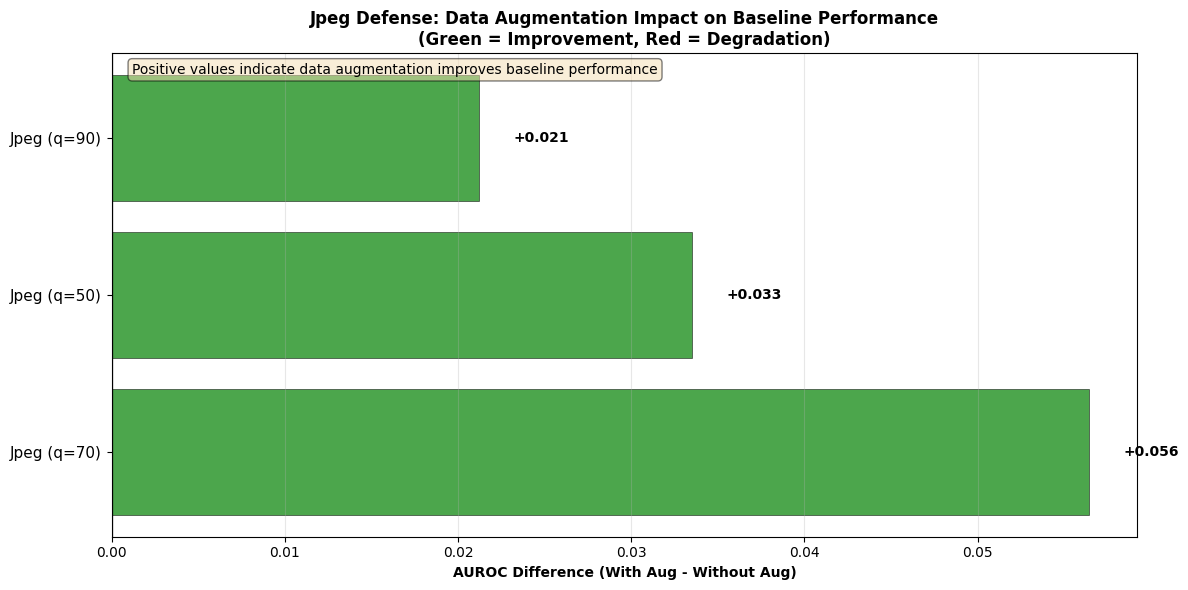

Saved publication-quality figures: ../img/defense_baseline_comparison/pgd/baseline_difference_jpeg.[png]


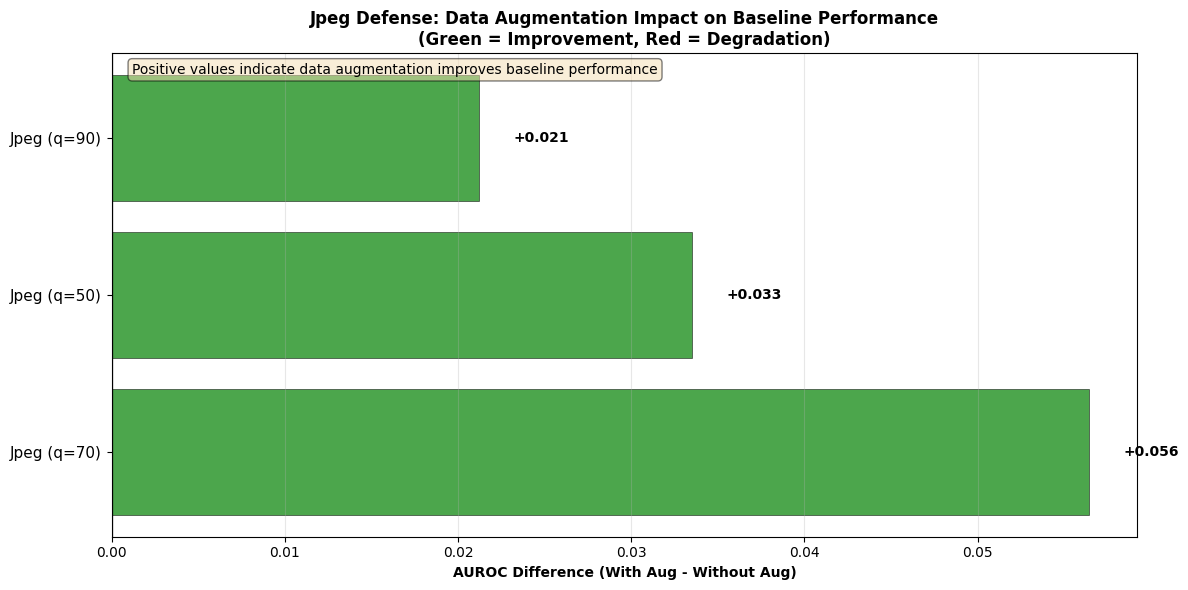

In [50]:
# Create individual baseline comparison plots for each defense type
print("Creating individual baseline comparison plots...")

# FGSM comparisons
plot_all_defense_baseline_comparisons_individual(results_fgsm_no_aug, results_fgsm_aug,
                                                save_fig=True, metric='AUROC', 
                                                folder="../img/defense_baseline_comparison/fgsm")

# PGD comparisons  
plot_all_defense_baseline_comparisons_individual(results_pgd_no_aug, results_pgd_aug,
                                                save_fig=True, metric='AUROC', 
                                                folder="../img/defense_baseline_comparison/pgd")

# Create individual difference analysis plots for specific defense types
defense_types = ['Gaussian', 'Spatial', 'Variance', 'Jpeg']

print("Creating individual difference analysis plots...")

for defense_type in defense_types:
    # FGSM
    plot_defense_baseline_difference_analysis_individual(results_fgsm_no_aug, results_fgsm_aug,
                                                       defense_type, save_fig=True, metric='AUROC', 
                                                       folder="../img/defense_baseline_comparison/fgsm")
    
    # PGD
    plot_defense_baseline_difference_analysis_individual(results_pgd_no_aug, results_pgd_aug,
                                                       defense_type, save_fig=True, metric='AUROC', 
                                                       folder="../img/defense_baseline_comparison/pgd")